In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path="clean.csv"
df = pd.read_csv(file_path)
df

,Respondent's current age,Respondent's year of birth,Highest educational level,Religion,Region,Type of place of residence,Current marital status,Age at first cohabitation,Age at first sex,Total children ever born,...,Heard family planning in newspaper/magazine las,Heard family planning by text messages on mobil,"Seen about family planning on facebook, twitter","Seen about family planning on poster, brochure","Seen about family planning on outdoor sign, bil",Heard family planning at community meetings eve,Visited health facility last,Source known for any method,Respondent worked in last,unmet_need_binary
0,39,1982,2,1,1,1,1,20.0,22,3,...,1,1,1,1,1,1,1,22,2,0
1,17,2004,2,1,1,1,3,16.0,16,0,...,1,1,1,1,0,0,1,98,0,0
2,29,1991,1,1,1,1,1,19.0,21,3,...,1,1,1,0,0,0,0,94,0,1
3,29,1991,1,1,1,1,1,19.0,21,3,...,1,1,1,0,0,0,0,94,0,1
4,40,1981,2,1,1,1,1,18.0,19,4,...,0,0,1,1,0,0,1,94,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6221,30,1991,1,1,25,2,1,14.0,14,2,...,0,0,0,0,0,0,0,14,0,0
6222,28,1993,1,1,25,2,1,12.0,14,5,...,0,0,0,0,0,0,0,14,0,0
6223,21,2000,1,1,25,2,1,14.0,14,2,...,0,0,0,1,0,0,0,14,0,0
6224,41,1980,1,1,25,2,1,22.0,23,3,...,0,1,0,0,0,0,0,94,2,0


In [8]:
print(df["unmet_need_binary"].values)

[0 0 1 ... 0 0 0]


Convert Unmet need to binary 

In [4]:
# Define mapping
unmet_need_map = {
    1: 1,  # Unmet need for spacing
    2: 1,  # Unmet need for limiting
    0: 0,  # Never had sex
    3: 0,  # Using for spacing
    4: 0,  # Using for limiting
    5: 0,  # Spacing failure
    6: 0,  # Limiting failure
    7: 0,  # No unmet need
    8: 0,  # Not married and no sex in last 30 days
    9: 0   # Infecund, menopausal
}

# Drop rows where Unmet need == 99
df = df[df["Unmet need"] != 99]

# Apply mapping
df["unmet_need_binary"] = df["Unmet need"].map(unmet_need_map)

# Drop rows with NaN (unmapped values, like 99 or unexpected codes)
df = df.dropna(subset=["unmet_need_binary"])

# Convert to integer safely
df["unmet_need_binary"] = df["unmet_need_binary"].astype(int)

print(df["unmet_need_binary"].value_counts())

unmet_need_binary
0    5206
1    1020
Name: count, dtype: int64


In [50]:
missing_values = df['unmet_need_binary'].isnull().sum()
print(f"Number of missing values in 'unmet_need_binary': {missing_values}")

Number of missing values in 'unmet_need_binary': 0


In [5]:
df['unmet_need_binary'].unique()

array([0, 1])

In [28]:
df_selected = df[["Respondent's current age", "Respondent's year of birth", 'Highest educational level', 'Religion', 'Region', 'Type of place of residence', 'Current marital status',
                   'Age at first cohabitation', 'Age at first sex', 'Total children ever born', 'Wealth index combined', 'Wealth index factor score combined (5 decimals)', 'Household has: electricity', 'Household has: radio',
                   'Household has: television', 'Household has: refrigerator', 'Household has: bicycle', 'Household has: motorcycle/scooter', 'Household has: car/truck', 'Type of toilet facility', 'Source of drinking water',
                   'Main floor material', 'Main wall material', 'Main roof material', 'Owns a mobile telephone', 'Has an account in a bank or other financial ins', 'Use of internet', 'Covered by health insurance',
                   'Health insurance type: mutual/community organiz', 'Health insurance type: provided by employer', 'Health insurance type: social security', 'Health insurance type: private/commercially pur', 'Health insurance type: other',
                   'Total children ever born', 'Births in last five years', 'Births in past year', 'Age of respondent at', 'Currently pregnant', 'Number of unions', 'Wanted last child', 'Wanted last pregnancy', 'Desire for more children',
                   'Ideal number of children', 'Ideal number of children (grouped)', "Husband's desire for children", 'Current contraceptive method', 'Current use by method type', 'Intention to use', 'Contraceptive use and intention',
                  'Number of living children', 'Parity at sterilization', 'Age of respondent at', 'Desire for more children', "Husband/partner's education level", "Husband/partner's occupation (grouped)", 
                  'Heard family planning on radio last few months', 'Heard family planning on TV last few months', 'Heard family planning in newspaper/magazine las', 'Heard family planning by text messages on mobil', 
                  'Seen about family planning on facebook, twitter', 'Seen about family planning on poster, brochure', 'Seen about family planning on outdoor sign, bil', 'Heard family planning at community meetings eve', 
                  'Visited health facility last', 'At health facility, told of family planning', 'Source known for any method', 'Told about side effects', 'Told how to deal with side effects', 'Respondent worked in last', 'Respondent employed all year/seasonal', 'unmet_need_binary']].copy()
df_selected.head()

,Respondent's current age,Respondent's year of birth,Highest educational level,Religion,Region,Type of place of residence,Current marital status,Age at first cohabitation,Age at first sex,Total children ever born,...,"Seen about family planning on outdoor sign, bil",Heard family planning at community meetings eve,Visited health facility last,"At health facility, told of family planning",Source known for any method,Told about side effects,Told how to deal with side effects,Respondent worked in last,Respondent employed all year/seasonal,unmet_need_binary
0,39,1982,2,1,1,1,1,20.0,22,3,...,1,1,1,1.0,22,0.0,1.0,2,1.0,0
1,17,2004,2,1,1,1,3,16.0,16,0,...,0,0,1,0.0,98,NaN,NaN,0,NaN,0
2,29,1991,1,1,1,1,1,19.0,21,3,...,0,0,0,NaN,94,NaN,NaN,0,NaN,1
3,29,1991,1,1,1,1,1,19.0,21,3,...,0,0,0,NaN,94,NaN,NaN,0,NaN,1
4,40,1981,2,1,1,1,1,18.0,19,4,...,0,0,1,1.0,94,NaN,NaN,1,1.0,0


In [23]:
print(df_selected.isnull().sum())

Respondent's current age                           0
Respondent's year of birth                         0
Highest educational level                          0
Religion                                           0
Region                                             0
                                                  ..
Heard family planning at community meetings eve    0
Visited health facility last                       0
Source known for any method                        0
Respondent worked in last                          0
unmet_need_binary                                  0
Length: 65, dtype: int64


In [24]:
df_selected.to_csv("df_selected_ml.csv", index=False)

In [25]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6226 entries, 0 to 6284
Data columns (total 65 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Respondent's current age                         6226 non-null   int64  
 1   Respondent's year of birth                       6226 non-null   int64  
 2   Highest educational level                        6226 non-null   int64  
 3   Religion                                         6226 non-null   int64  
 4   Region                                           6226 non-null   int64  
 5   Type of place of residence                       6226 non-null   int64  
 6   Current marital status                           6226 non-null   int64  
 7   Age at first cohabitation                        6209 non-null   float64
 8   Age at first sex                                 6226 non-null   int64  
 9   Total children ever born           

In [29]:
# drop highly missing columns
df_selected=df_selected.drop(['Parity at sterilization', 'Intention to use', 'Told about side effects', 'Told how to deal with side effects', 'At health facility, told of family planning', 'Respondent employed all year/seasonal'], axis=1)

In [65]:
duplicate_columns = df_selected.columns.duplicated()
# Filter out duplicate columns to keep only the first occurrence of each name
df_selected = df_selected.loc[:, ~duplicate_columns]

In [66]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6226 entries, 0 to 6284
Data columns (total 63 columns):
 #   Column                                           Non-Null Count  Dtype   
---  ------                                           --------------  -----   
 0   Respondent's current age                         6226 non-null   int64   
 1   Respondent's year of birth                       6226 non-null   int64   
 2   Highest educational level                        6226 non-null   int64   
 3   Religion                                         6226 non-null   int64   
 4   Region                                           6226 non-null   int64   
 5   Type of place of residence                       6226 non-null   int64   
 6   Current marital status                           6226 non-null   int64   
 7   Age at first cohabitation                        6226 non-null   float64 
 8   Age at first sex                                 6226 non-null   int64   
 9   Total children ever born

In [30]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6226 entries, 0 to 6284
Data columns (total 65 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Respondent's current age                         6226 non-null   int64  
 1   Respondent's year of birth                       6226 non-null   int64  
 2   Highest educational level                        6226 non-null   int64  
 3   Religion                                         6226 non-null   int64  
 4   Region                                           6226 non-null   int64  
 5   Type of place of residence                       6226 non-null   int64  
 6   Current marital status                           6226 non-null   int64  
 7   Age at first cohabitation                        6209 non-null   float64
 8   Age at first sex                                 6226 non-null   int64  
 9   Total children ever born           

In [35]:
# Fill numeric with median
num_impute = ['Age at first cohabitation', 'Age of respondent at', 'Number of unions']
for col in num_impute:
    df_selected[col] = df_selected[col].fillna(df_selected[col].median())

In [37]:
# Fill categorical with mode
cat_impute = ['Husband/partner\'s education level', 'Husband/partner\'s occupation (grouped)',
              'Wanted last child', 'Husband\'s desire for children']
for col in cat_impute:
    df_selected[col] = df_selected[col].fillna(df_selected[col].mode()[0])

In [39]:
df_selected['Number of unions'].isnull().sum()

np.int64(0)

In [63]:
df_check = df_selected[["Respondent's current age", "Number of living children"]]
df_check

,Respondent's current age,Number of living children
0,39,3
1,17,0
2,29,3
3,29,3
4,40,4
...,...,...
6280,30,2
6281,28,5
6282,21,2
6283,41,2


<Axes: xlabel='unmet_need_binary'>

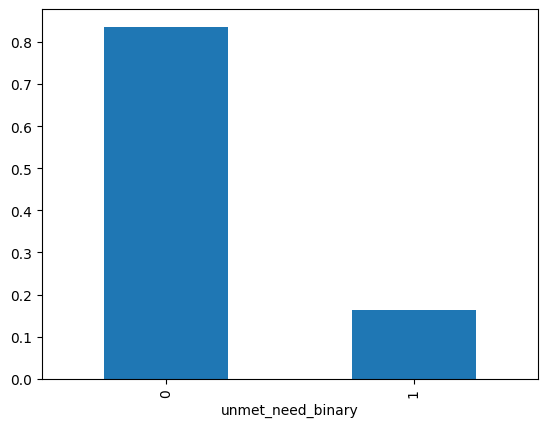

In [42]:
df_selected['unmet_need_binary'].value_counts(normalize=True).plot(kind='bar')

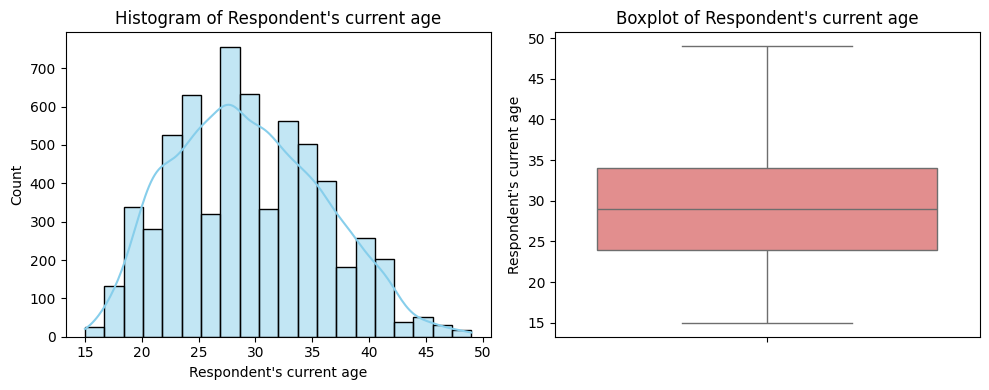

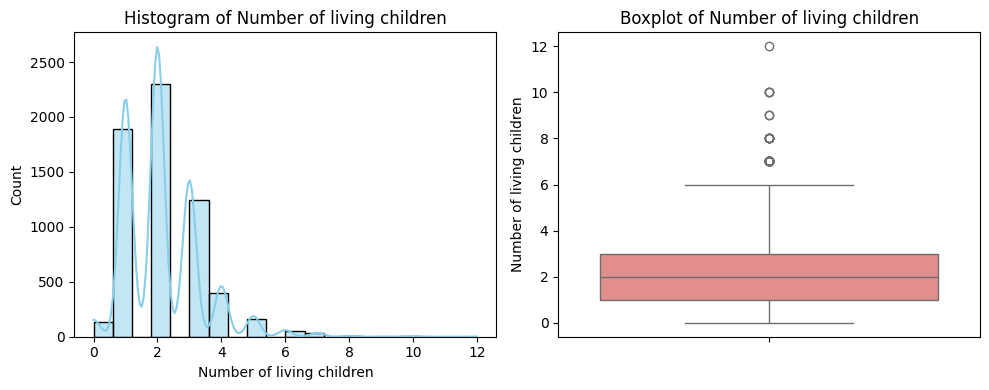

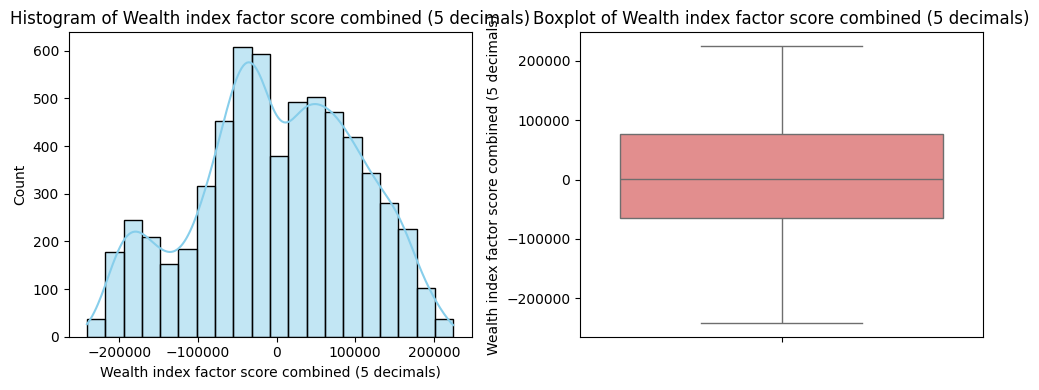

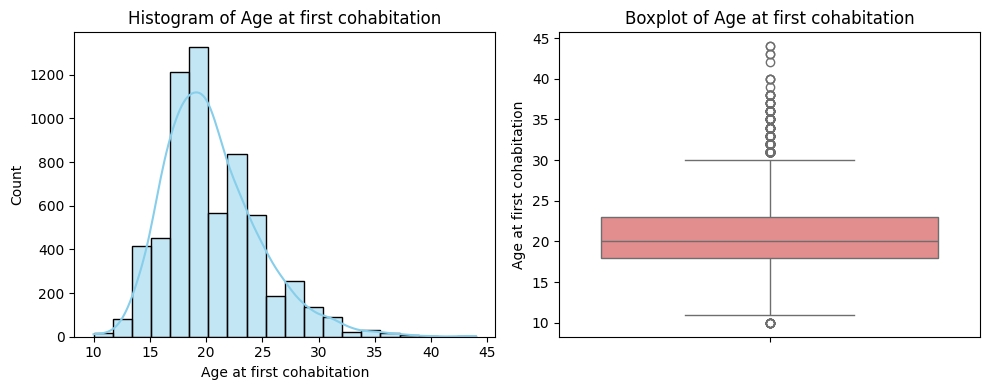

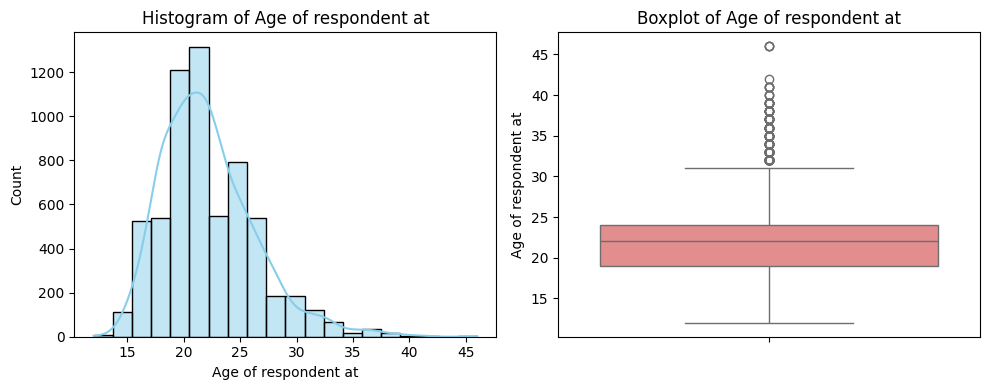

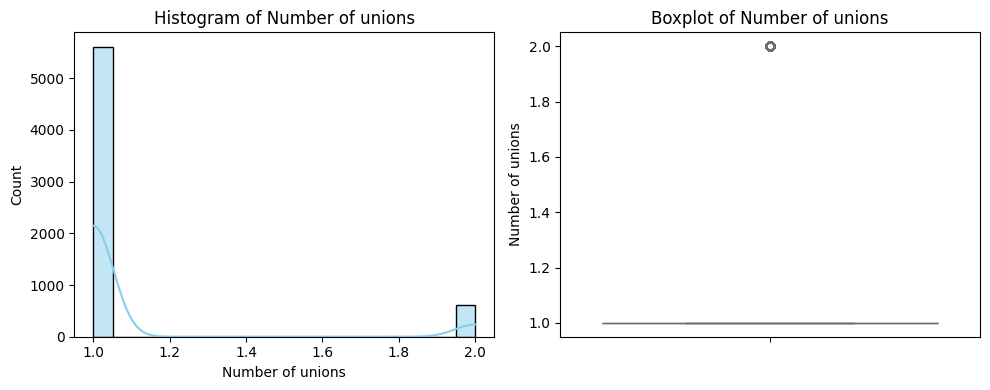

In [67]:
numeric_features = [
    "Respondent's current age", 
    "Number of living children", 
    "Wealth index factor score combined (5 decimals)",
    "Age at first cohabitation", 
    "Age of respondent at", 
    "Number of unions"
]

for col in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    
    # Histogram + KDE
    sns.histplot(df_selected[col], kde=True, bins=20, ax=axes[0], color="skyblue")
    axes[0].set_title(f"Histogram of {col}")
    
    # Boxplot
    sns.boxplot(y=df_selected[col], ax=axes[1], color="lightcoral")
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14320\918909165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="viridis")


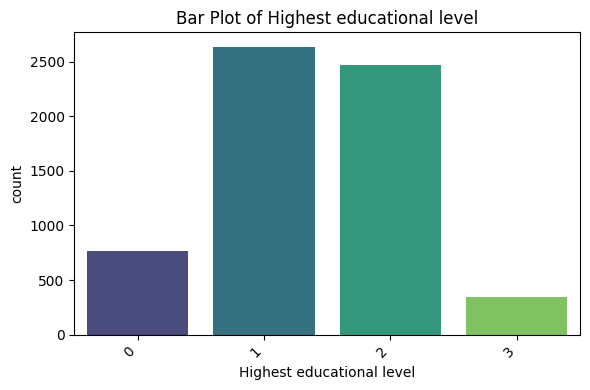

C:\Users\HP\AppData\Local\Temp\ipykernel_14320\918909165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="viridis")


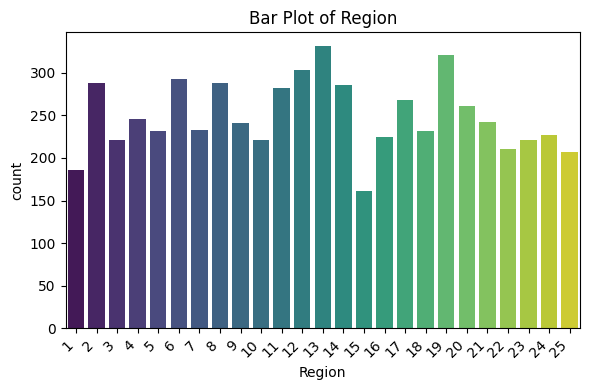

C:\Users\HP\AppData\Local\Temp\ipykernel_14320\918909165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="viridis")


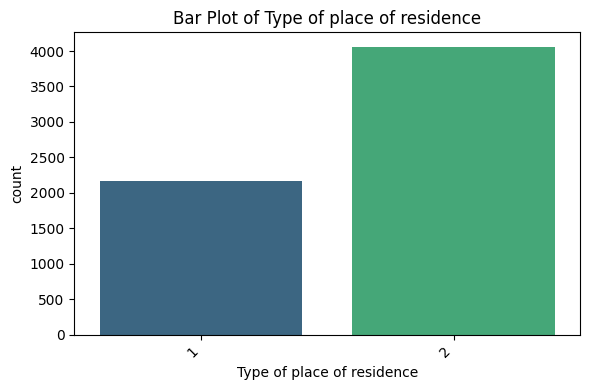

C:\Users\HP\AppData\Local\Temp\ipykernel_14320\918909165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="viridis")


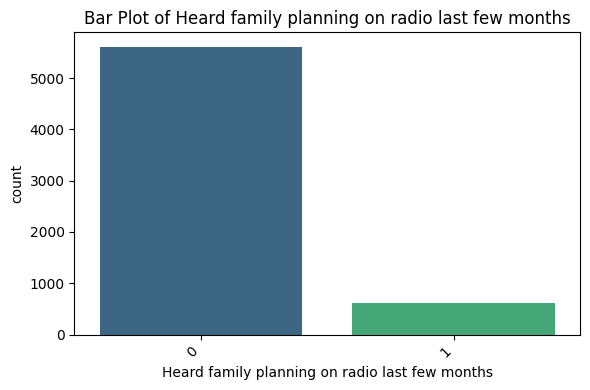

In [44]:
categorical_features = [
    "Highest educational level",
    "Region",
    "Type of place of residence",
    "Heard family planning on radio last few months"
]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette="viridis")
    plt.title(f"Bar Plot of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

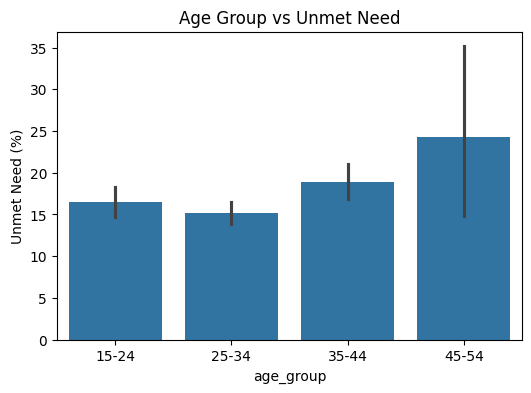

In [47]:
# Create age groups
df_selected['age_group'] = pd.cut(df_selected["Respondent's current age"], 
                         bins=[15, 24, 34, 44, 54],
                         labels=['15-24','25-34','35-44','45-54'])

plt.figure(figsize=(6,4))
sns.barplot(x='age_group', y='unmet_need_binary', data=df_selected, estimator=lambda x: 100*sum(x)/len(x))
plt.ylabel("Unmet Need (%)")
plt.title("Age Group vs Unmet Need")
plt.show()

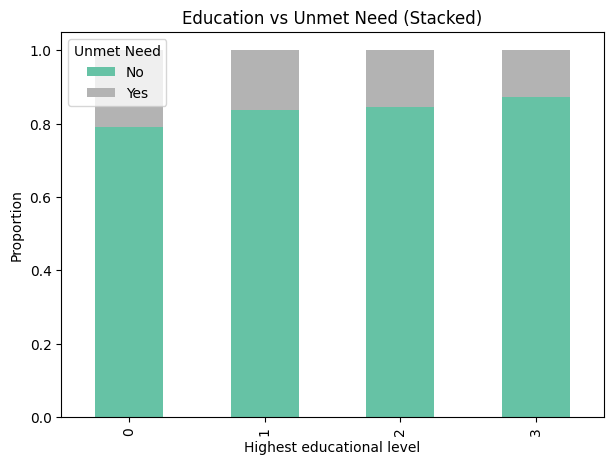

In [46]:
edu_vs_need = pd.crosstab(df_selected['Highest educational level'], df_selected['unmet_need_binary'], normalize='index')

edu_vs_need.plot(kind='bar', stacked=True, colormap='Set2', figsize=(7,5))
plt.title("Education vs Unmet Need (Stacked)")
plt.ylabel("Proportion")
plt.legend(title="Unmet Need", labels=['No','Yes'])
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_14320\3896530759.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Wealth index factor score combined (5 decimals)',


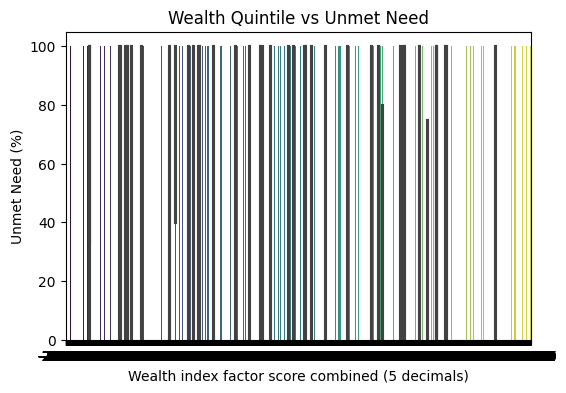

In [48]:
plt.figure(figsize=(6,4))
sns.barplot(x='Wealth index factor score combined (5 decimals)', 
            y='unmet_need_binary', data=df_selected, estimator=lambda x: 100*sum(x)/len(x), palette='viridis')
plt.ylabel("Unmet Need (%)")
plt.title("Wealth Quintile vs Unmet Need")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14320\4063300282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Heard family planning on radio last few months',


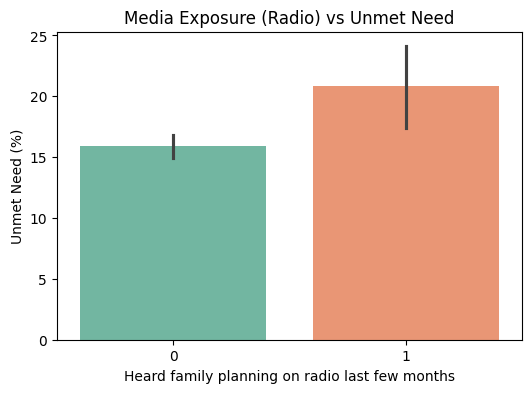

In [49]:
plt.figure(figsize=(6,4))
sns.barplot(x='Heard family planning on radio last few months', 
            y='unmet_need_binary', data=df, estimator=lambda x: 100*sum(x)/len(x), palette='Set2')
plt.ylabel("Unmet Need (%)")
plt.title("Media Exposure (Radio) vs Unmet Need")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14320\594316474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type of place of residence', y='unmet_need_binary', data=df,


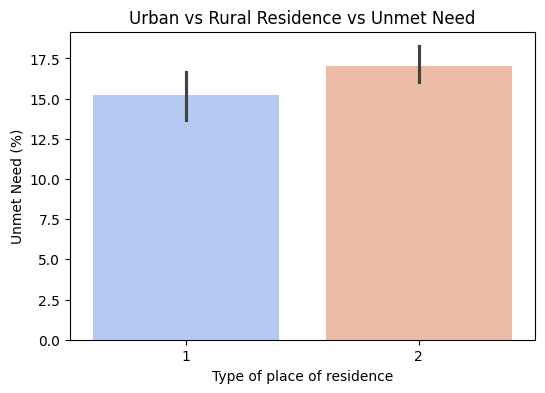

In [50]:
plt.figure(figsize=(6,4))
sns.barplot(x='Type of place of residence', y='unmet_need_binary', data=df, 
            estimator=lambda x: 100*sum(x)/len(x), palette='coolwarm')
plt.ylabel("Unmet Need (%)")
plt.title("Urban vs Rural Residence vs Unmet Need")
plt.show()

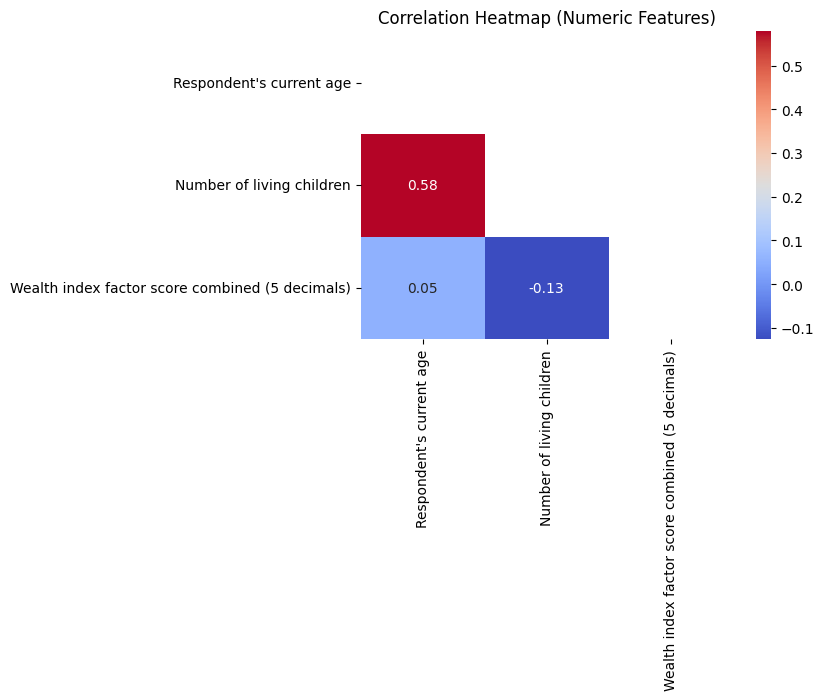

In [55]:
# Select numeric features
numeric_cols = [
    "Respondent's current age",
    "Number of living children",
    "Wealth index factor score combined (5 decimals)"
]

# Compute correlation
corr = df_selected[numeric_cols].corr()

# Heatmap (upper triangle only)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(6,4))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [59]:
from scipy.stats import chi2_contingency

categorical_tests = [
    "Highest educational level",
    "Type of place of residence",
    "Region",
    "Desire for more children",
    "Husband/partner's education level",
    "Husband/partner's occupation (grouped)",
    "Heard family planning on radio last few months",
    "Heard family planning on TV last few months",
    "Seen about family planning on facebook, twitter",
    "Heard family planning at community meetings eve",
    
]

for col in categorical_tests:
    print(f"\nChi-Square Test: {col} vs unmet_need_binary")
    table = pd.crosstab(df[col], df_selected['unmet_need_binary'])
    display(table)  # show crosstab
    
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"Chi2 = {chi2:.3f}, p-value = {p:.5f}, dof = {dof}")
    if p < 0.05:
        print("👉 Significant association")
    else:
        print("👉 No significant association")



Chi-Square Test: Highest educational level vs unmet_need_binary


unmet_need_binary,0,1
Highest educational level,,
0,603,161
1,2210,429
2,2090,386
3,303,44


Chi2 = 16.911, p-value = 0.00074, dof = 3
👉 Significant association

Chi-Square Test: Type of place of residence vs unmet_need_binary


unmet_need_binary,0,1
Type of place of residence,,
1,1836,329
2,3370,691


Chi2 = 3.280, p-value = 0.07012, dof = 1
👉 No significant association

Chi-Square Test: Region vs unmet_need_binary


...

Chi2 = 0.381, p-value = 0.53696, dof = 1
👉 No significant association

Chi-Square Test: Seen about family planning on facebook, twitter vs unmet_need_binary


unmet_need_binary,0,1
"Seen about family planning on facebook, twitter",,
0,3393,718
1,1813,302


Chi2 = 10.119, p-value = 0.00147, dof = 1
👉 Significant association

Chi-Square Test: Heard family planning at community meetings eve vs unmet_need_binary


unmet_need_binary,0,1
Heard family planning at community meetings eve,,
0,4480,902
1,726,118


Chi2 = 3.911, p-value = 0.04796, dof = 1
👉 Significant association


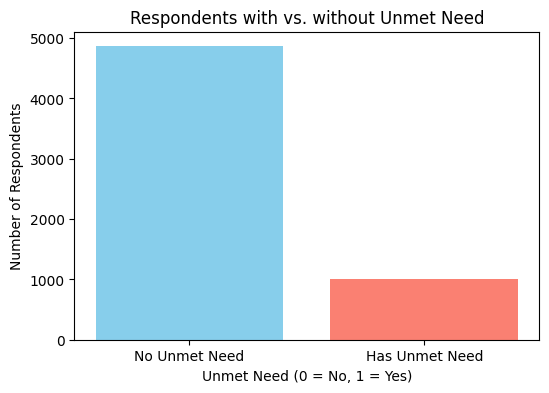

In [ ]:
# Count unmet need vs no unmet need
counts = df_selected["unmet_need_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values, color=["skyblue", "salmon"])
plt.title("Respondents with vs. without Unmet Need")
plt.xlabel("Unmet Need (0 = No, 1 = Yes)")
plt.ylabel("Number of Respondents")
plt.xticks([0, 1], ["No Unmet Need", "Has Unmet Need"])
plt.show()

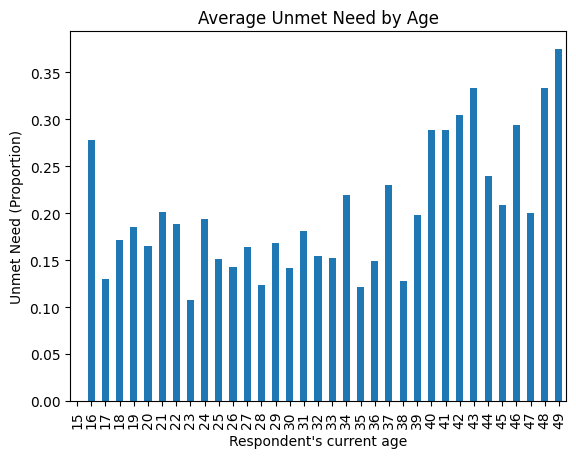

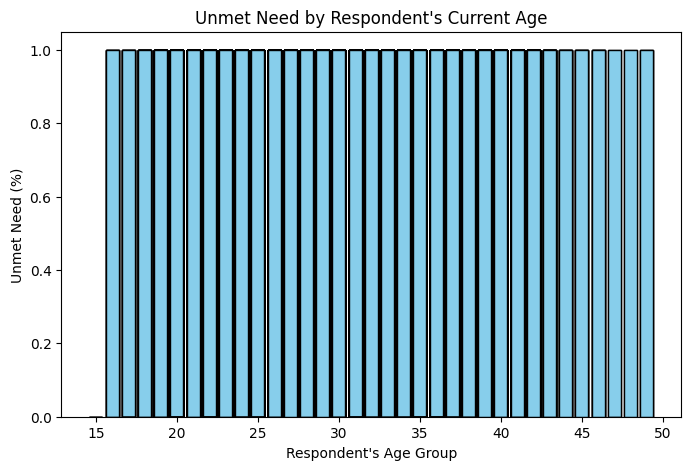

In [123]:
df_cleaned.groupby("Respondent's current age")["unmet_need_binary"].mean().plot(kind="bar")
plt.title("Average Unmet Need by Age")
plt.ylabel("Unmet Need (Proportion)")
plt.show()

# --- Using matplotlib ---
plt.figure(figsize=(8, 5))
plt.bar(df_cleaned["Respondent's current age"], df_cleaned["unmet_need_binary"], color="skyblue", edgecolor="black")
plt.title("Unmet Need by Respondent's Current Age")
plt.xlabel("Respondent's Age Group")
plt.ylabel("Unmet Need (%)")
plt.show()

## Categorical Variable

C:\Users\HP\AppData\Local\Temp\ipykernel_7400\544395040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Highest educational level', data=df_cleaned, palette='viridis')


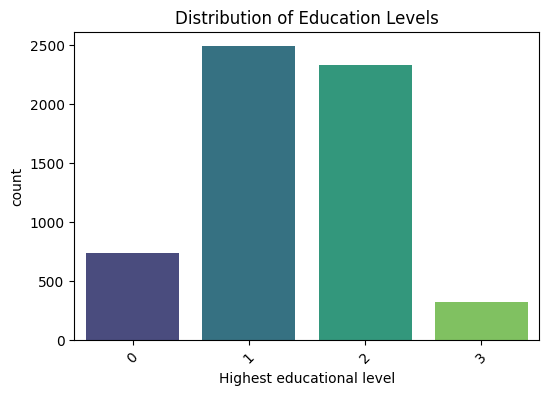

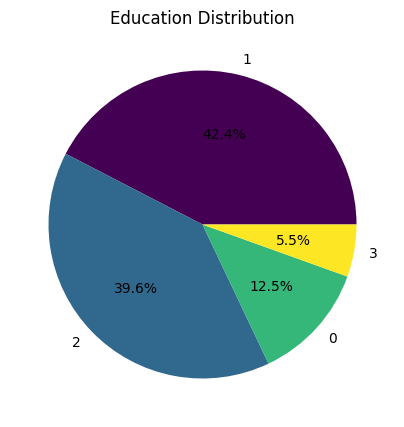

In [124]:
# Example: Categorical variable 'education'
plt.figure(figsize=(6,4))
sns.countplot(x='Highest educational level', data=df_cleaned, palette='viridis')
plt.title("Distribution of Education Levels")
plt.xticks(rotation=45)
plt.show()

df_cleaned['Highest educational level'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5), cmap='viridis')
plt.title("Education Distribution")
plt.ylabel("")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7400\17479158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Wealth index combined', data=df, palette='viridis')


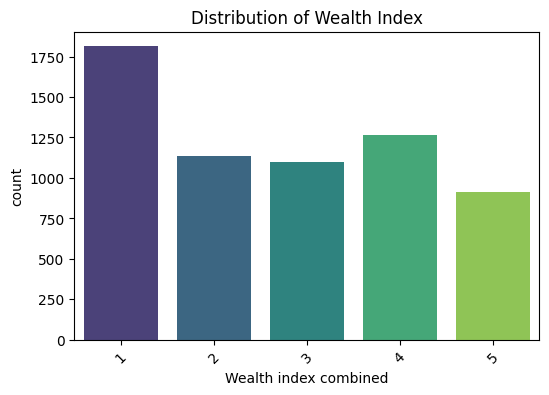

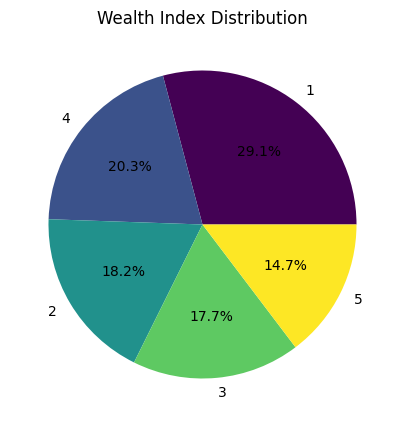

In [104]:
# Example: Categorical variable 'wealth index'
plt.figure(figsize=(6,4))
sns.countplot(x='Wealth index combined', data=df, palette='viridis')
plt.title("Distribution of Wealth Index")
plt.xticks(rotation=45)
plt.show()

df['Wealth index combined'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5), cmap='viridis')
plt.title("Wealth Index Distribution")
plt.ylabel("")
plt.show()

* 1   Banteay Meanchey
* 2   Battambang
* 3   Kampong Cham
* 4   Kampong Chhnang
* 5   Kampong Speu
* 6   Kampong Thom
* 7   Kampot
* 8   Kandal
* 9   Koh Kong
* 10  Kratie
* 11  Mondul Kiri
* 12  Phnom Penh
* 13  Preah Vihear
* 14  Prey Veng
* 15  Pursat
* 16  Ratanak Kiri
* 17  Siemreap
* 18  Preah Sihanouk
* 19  Stung Treng
* 20  Svay Rieng
* 21  Takeo
* 22  Otdar Meanchey
* 23  Kep
* 24  Pailin
* 25  Tboung Khmum

C:\Users\HP\AppData\Local\Temp\ipykernel_7400\1628552934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region', data=df_cleaned, palette='viridis')


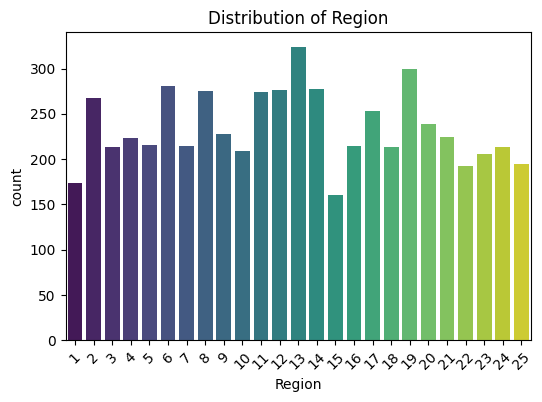

In [125]:
# Example: Categorical variable 'Region'
plt.figure(figsize=(6,4))
sns.countplot(x='Region', data=df_cleaned, palette='viridis')
plt.title("Distribution of Region")
plt.xticks(rotation=45)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7400\981853718.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type of place of residence', data=df_cleaned, palette='viridis')


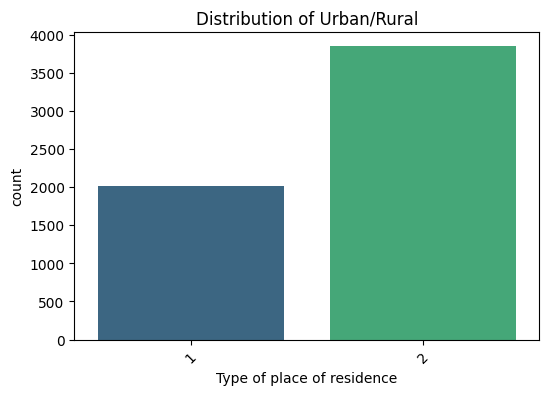

In [126]:
# Example: Categorical variable 'Urban/Rural'
plt.figure(figsize=(6,4))
sns.countplot(x='Type of place of residence', data=df_cleaned, palette='viridis')
plt.title("Distribution of Urban/Rural")
plt.xticks(rotation=45)
plt.show()

## Categorical Variables

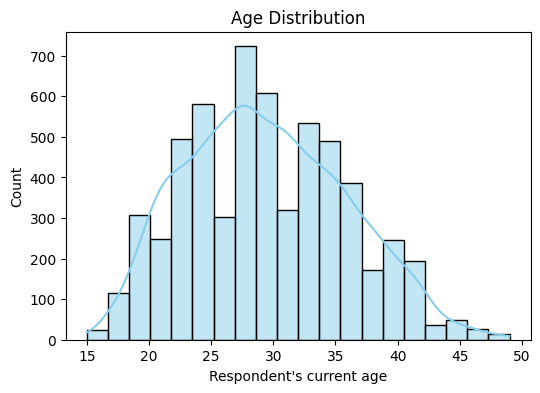

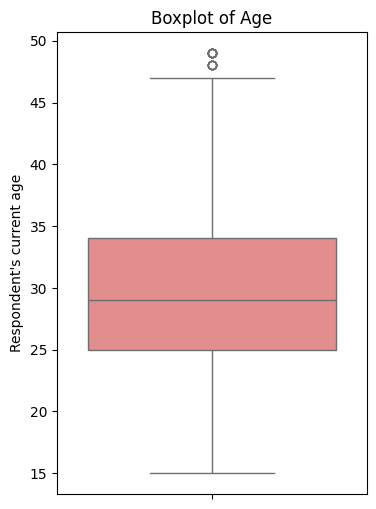

In [127]:
# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned["Respondent's current age"], kde=True, bins=20, color='skyblue')
plt.title("Age Distribution")
plt.show()

# Boxplot
plt.figure(figsize=(4,6))
sns.boxplot(y=df_cleaned["Respondent's current age"], color='lightcoral')
plt.title("Boxplot of Age")
plt.show()

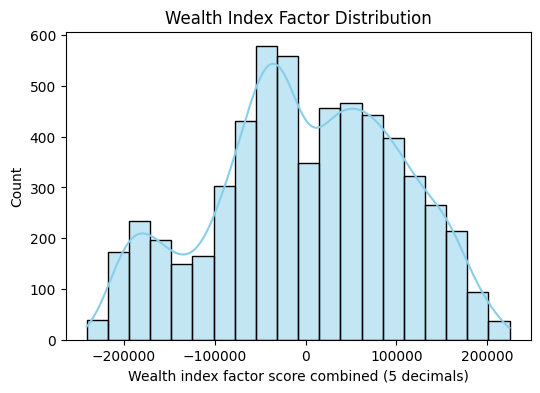

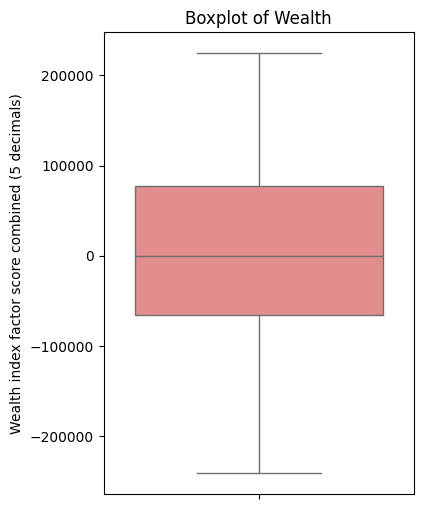

In [128]:
# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['Wealth index factor score combined (5 decimals)'], kde=True, bins=20, color='skyblue')
plt.title("Wealth Index Factor Distribution")
plt.show()

# Boxplot
plt.figure(figsize=(4,6))
sns.boxplot(y=df_cleaned['Wealth index factor score combined (5 decimals)'], color='lightcoral')
plt.title("Boxplot of Wealth")
plt.show()

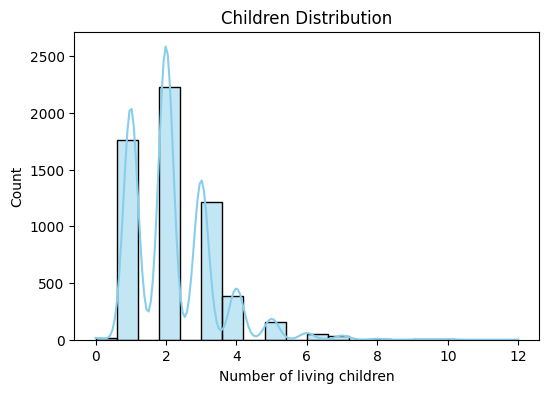

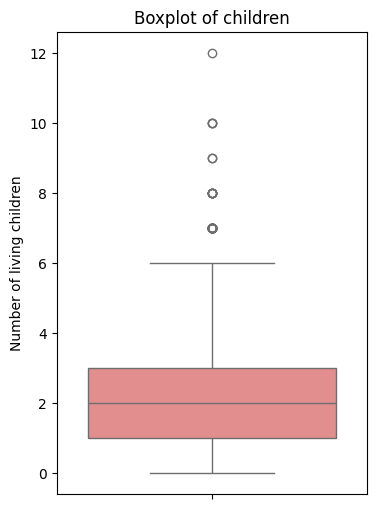

In [129]:
# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['Number of living children'], kde=True, bins=20, color='skyblue')
plt.title("Children Distribution")
plt.show()

# Boxplot
plt.figure(figsize=(4,6))
sns.boxplot(y=df_cleaned['Number of living children'], color='lightcoral')
plt.title("Boxplot of children")
plt.show()

## Categorical predictor vs variable

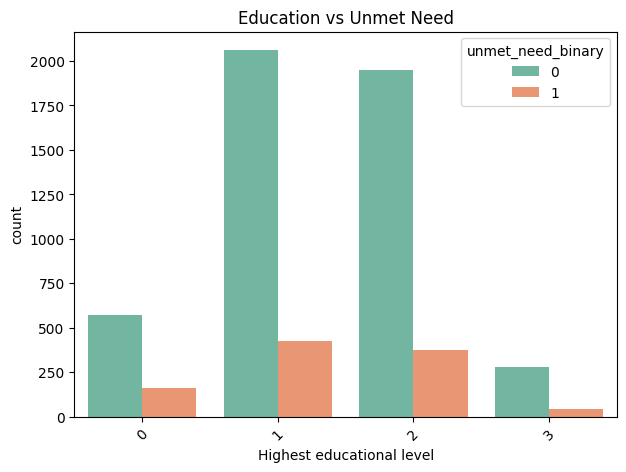

In [130]:
# Group Bar Plot
plt.figure(figsize=(7,5))
sns.countplot(x='Highest educational level', hue='unmet_need_binary', data=df_cleaned, palette='Set2')
plt.title("Education vs Unmet Need")
plt.xticks(rotation=45)
plt.show()

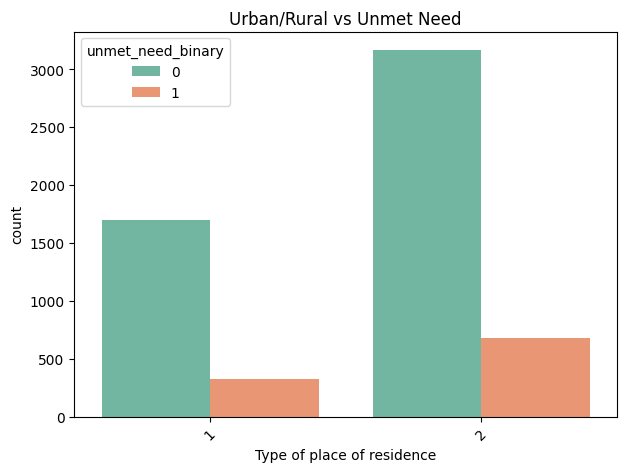

In [131]:
# Group Bar Plot
plt.figure(figsize=(7,5))
sns.countplot(x='Type of place of residence', hue='unmet_need_binary', data=df_cleaned, palette='Set2')
plt.title("Urban/Rural vs Unmet Need")
plt.xticks(rotation=45)
plt.show()

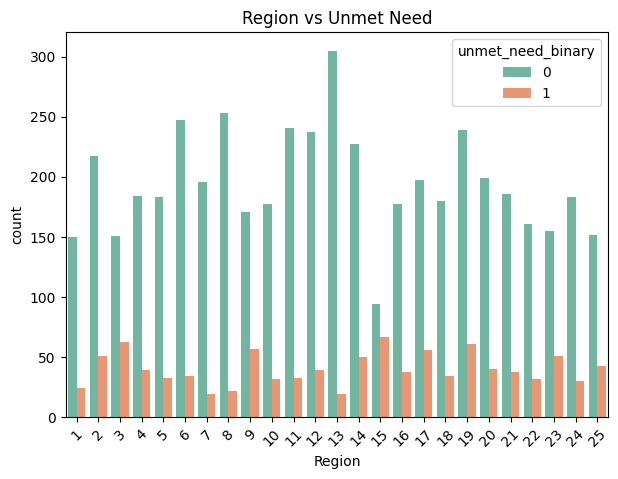

In [132]:
# Group Bar Plot
plt.figure(figsize=(7,5))
sns.countplot(x='Region', hue='unmet_need_binary', data=df_cleaned, palette='Set2')
plt.title("Region vs Unmet Need")
plt.xticks(rotation=45)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7400\805040304.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chi2_results = pd.concat([chi2_results, pd.DataFrame([[col, chi2, p]],


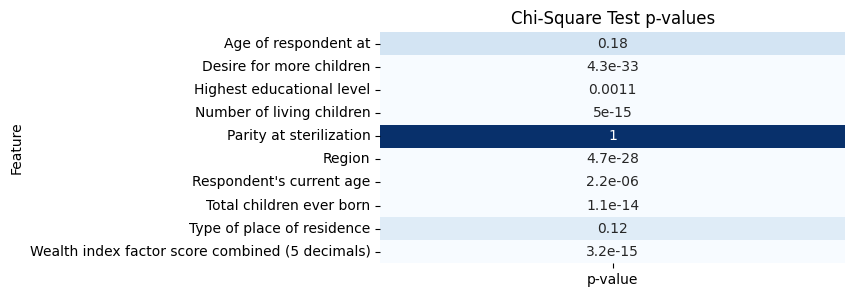

In [137]:
from scipy.stats import chi2_contingency

categorical_cols = ["Respondent's current age", 'Wealth index factor score combined (5 decimals)', 'Highest educational level', 'Region', 'Type of place of residence', 'Total children ever born', 
                  'Number of living children', 'Parity at sterilization', 'Age of respondent at', 'Desire for more children']
chi2_results = pd.DataFrame(columns=['Feature', 'Chi2', 'p-value'])

for col in categorical_cols:
    table = pd.crosstab(df[col], df_cleaned['unmet_need_binary'])
    chi2, p, dof, ex = chi2_contingency(table)
    chi2_results = pd.concat([chi2_results, pd.DataFrame([[col, chi2, p]], 
                                                          columns=['Feature', 'Chi2', 'p-value'])])

plt.figure(figsize=(6,3))
sns.heatmap(chi2_results.pivot_table(index='Feature', values='p-value'), 
            annot=True, cmap="Blues", cbar=False)
plt.title("Chi-Square Test p-values")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7400\3052534484.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chi2_results = pd.concat([chi2_results, pd.DataFrame([[col, chi2, p]],


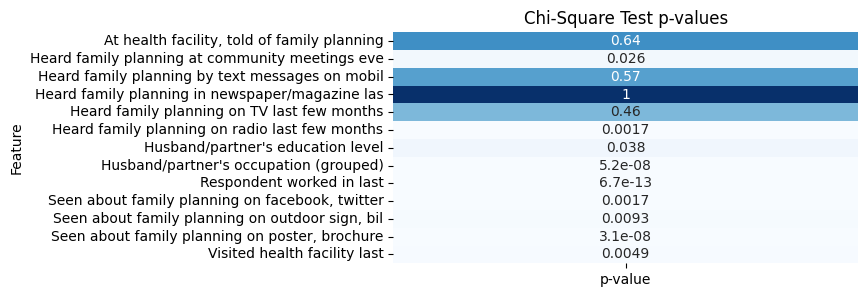

In [134]:
from scipy.stats import chi2_contingency

categorical_cols = ["Husband/partner's education level", "Husband/partner's occupation (grouped)", 
                  'Heard family planning on radio last few months', 'Heard family planning on TV last few months', 'Heard family planning in newspaper/magazine las', 'Heard family planning by text messages on mobil', 
                  'Seen about family planning on facebook, twitter', 'Seen about family planning on poster, brochure', 'Seen about family planning on outdoor sign, bil', 'Heard family planning at community meetings eve', 
                  'Visited health facility last', 'At health facility, told of family planning', 'Respondent worked in last']
chi2_results = pd.DataFrame(columns=['Feature', 'Chi2', 'p-value'])

for col in categorical_cols:
    table = pd.crosstab(df[col], df_cleaned['unmet_need_binary'])
    chi2, p, dof, ex = chi2_contingency(table)
    chi2_results = pd.concat([chi2_results, pd.DataFrame([[col, chi2, p]], 
                                                          columns=['Feature', 'Chi2', 'p-value'])])

plt.figure(figsize=(6,3))
sns.heatmap(chi2_results.pivot_table(index='Feature', values='p-value'), 
            annot=True, cmap="Blues", cbar=False)
plt.title("Chi-Square Test p-values")
plt.show()

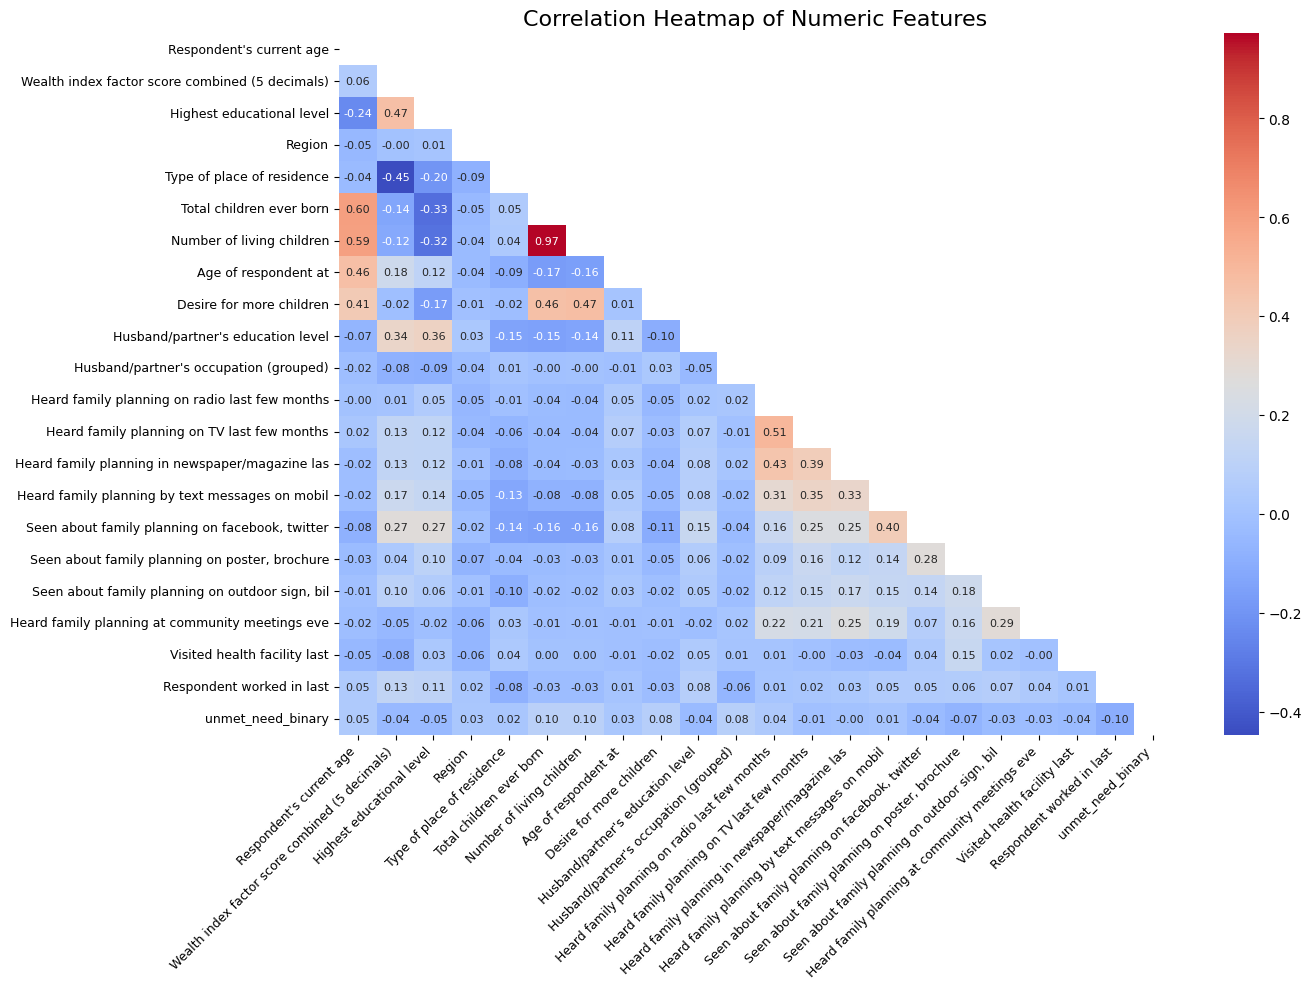

In [140]:
# Correlation Heatmap for Numeric Features
# Compute correlation matrix
numeric_cols = df_cleaned.select_dtypes(include=['int64','float64']).columns
corr_matrix = df_cleaned[numeric_cols].corr()

# Mask to show only upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
            cbar=True, annot_kws={"size":8})

plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## Split data

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import Counter

In [13]:
# 1. Features & Target
X = df.drop(columns=["unmet_need_binary", "Wealth index combined", "Religion",
                      "Type of place of residence", "Age at first cohabitation", "Age at first sex",
                      "Household has: electricity", "Household has: radio", "Type of toilet facility", "Has an account in a bank or other financial ins",
                      "Covered by health insurance",
                      "Health insurance type: mutual/community organiz",
                      "Health insurance type: provided by employer",
                      "Health insurance type: social security",
                      "Health insurance type: private/commercially pur",
                      "Health insurance type: other",
                      "Age of respondent at",
                      "Ideal number of children (grouped)",
                      "Husband's desire for children",
                      "Heard family planning on TV last few months",
                      "Heard family planning in newspaper/magazine las",
                      "Heard family planning by text messages on mobil"])
y = df["unmet_need_binary"]

print(f"Original dataset shape: {Counter(y)}")

Original dataset shape: Counter({0: 5206, 1: 1020})


In [14]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Training set before SMOTE: {Counter(y_train)}")

Training set before SMOTE: Counter({0: 3644, 1: 714})


In [15]:
# 3. Apply SMOTE ONLY to the training data
# This creates synthetic samples for the minority class to balance the set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Training set after SMOTE: {Counter(y_train_resampled)}")

Training set after SMOTE: Counter({0: 3644, 1: 3644})


## Logistic Regression

Class Weights: {0: 1.0, 1: 1.0}
Epoch 10/50 - Loss: 0.5167, Acc: 0.8769
Epoch 20/50 - Loss: 0.2985, Acc: 0.8844
Epoch 30/50 - Loss: 0.2705, Acc: 0.8865
Epoch 40/50 - Loss: 0.2597, Acc: 0.8844
Epoch 50/50 - Loss: 0.2549, Acc: 0.8833


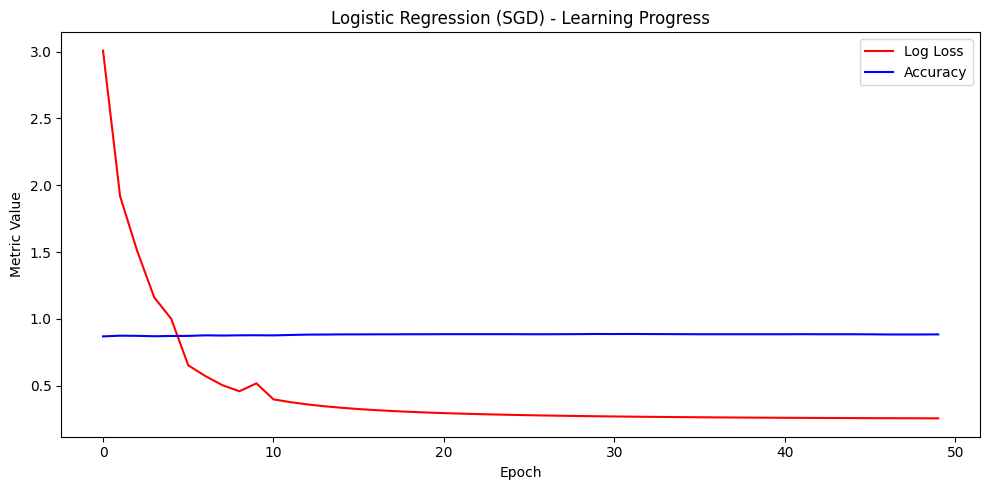


===== Logistic Regression Evaluation =====
Accuracy:  0.8833
Precision: 0.6302
Recall:    0.6961
F1-Score:  0.6615
ROC-AUC:   0.9384


C:\Users\HP\AppData\Local\Temp\ipykernel_13568\4167302258.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_features, palette="viridis")


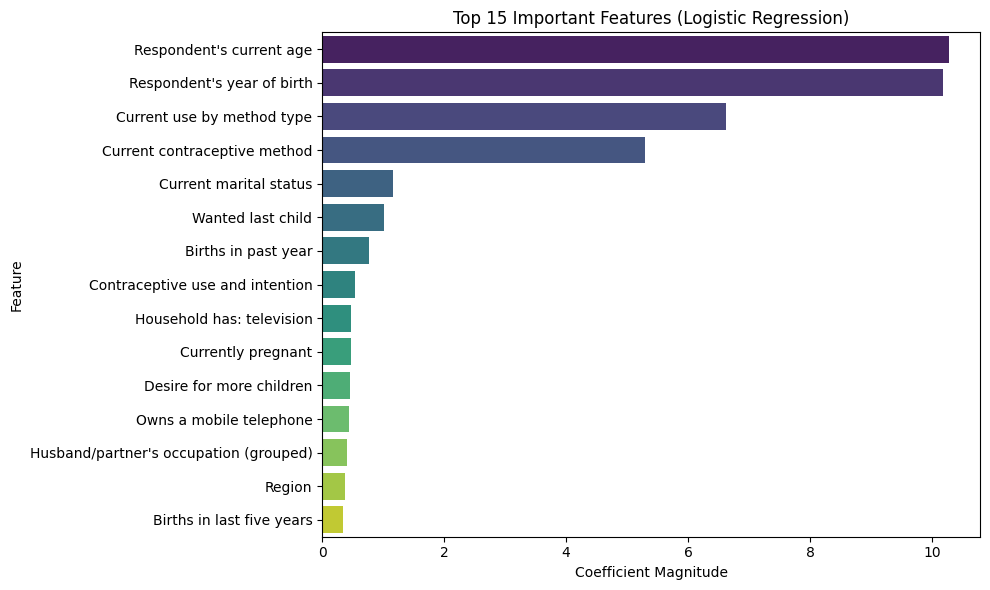

In [20]:
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, log_loss, precision_score, recall_score, f1_score, roc_auc_score

# Scale features
# Scale features but keep as DataFrames
scaler = StandardScaler()
X_train_np = pd.DataFrame(
    scaler.fit_transform(X_train_resampled),
    columns=X_train_resampled.columns,
    index=X_train_resampled.index
)
X_test_np = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

y_train_np = y_train_resampled.to_numpy()
y_test_np = y_test.to_numpy()

# ======================================================
# 5️⃣ Compute balanced class weights manually (fix IndexError)
# ======================================================
classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_np)
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}
print("Class Weights:", class_weight_dict)

# ======================================================
# 6️⃣ Logistic Regression using SGDClassifier (iterative)
# ======================================================
log_reg = SGDClassifier(
    loss='log_loss',
    max_iter=1,                # Manual iteration
    learning_rate='optimal',
    tol=None,
    random_state=42
)

n_epochs = 50
losses, accuracies = [], []

# Precompute sample weights
sample_weights = np.array([class_weight_dict[int(y)] for y in y_train_np])

for epoch in range(n_epochs):
    log_reg.partial_fit(X_train_np, y_train_np, classes=classes, sample_weight=sample_weights)
    
    y_pred_proba = log_reg.predict_proba(X_test_np)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    losses.append(log_loss(y_test_np, y_pred_proba))
    accuracies.append(accuracy_score(y_test_np, y_pred))
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Loss: {losses[-1]:.4f}, Acc: {accuracies[-1]:.4f}")

# ======================================================
# 7️⃣ Plot loss and accuracy over epochs
# ======================================================
plt.figure(figsize=(10,5))
plt.plot(losses, label='Log Loss', color='red')
plt.plot(accuracies, label='Accuracy', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Logistic Regression (SGD) - Learning Progress')
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# 8️⃣ Final evaluation
# ======================================================
y_pred = log_reg.predict(X_test_np)
y_pred_proba = log_reg.predict_proba(X_test_np)[:, 1]

print("\n===== Logistic Regression Evaluation =====")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test_np, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test_np, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_np, y_pred_proba):.4f}")

# ======================================================
# 9️⃣ Feature importance visualization
# ======================================================
importance = np.abs(log_reg.coef_[0])
sorted_idx = np.argsort(importance)[::-1]
top_features = np.array(X_train_np.columns)[sorted_idx][:15]
top_values = importance[sorted_idx][:15]

plt.figure(figsize=(10,6))
sns.barplot(x=top_values, y=top_features, palette="viridis")
plt.title("Top 15 Important Features (Logistic Regression)")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

Training Random Forest...


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributio

Epoch 10/50 - Trees: 20 - Loss: 0.2085, Acc: 0.8913


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributio

Epoch 20/50 - Trees: 40 - Loss: 0.2029, Acc: 0.8945


...

Epoch 30/50 - Trees: 60 - Loss: 0.2030, Acc: 0.8945


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributio

Epoch 40/50 - Trees: 80 - Loss: 0.2032, Acc: 0.8940


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributio

Epoch 50/50 - Trees: 100 - Loss: 0.2027, Acc: 0.8951


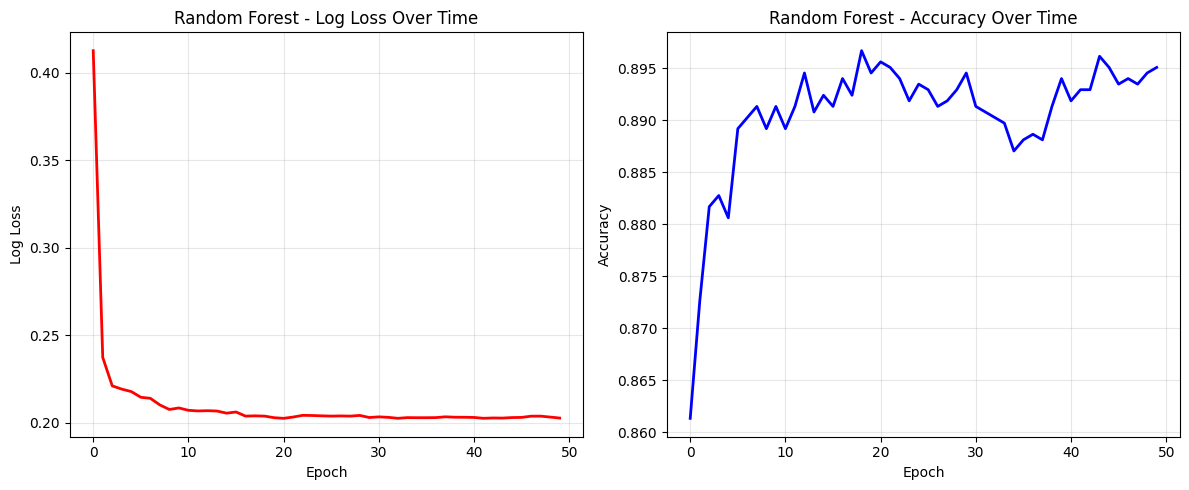


Random Forest - Final Evaluation
Accuracy:  0.8951
Precision: 0.6244
Recall:    0.9020
F1-Score:  0.7380
ROC-AUC:   0.9651

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      1562
           1       0.62      0.90      0.74       306

    accuracy                           0.90      1868
   macro avg       0.80      0.90      0.84      1868
weighted avg       0.92      0.90      0.90      1868



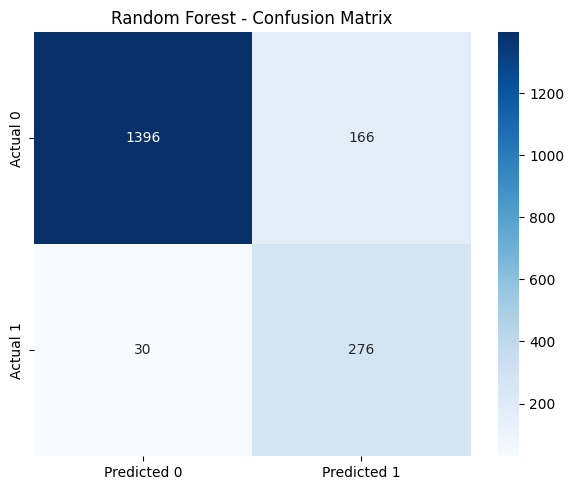

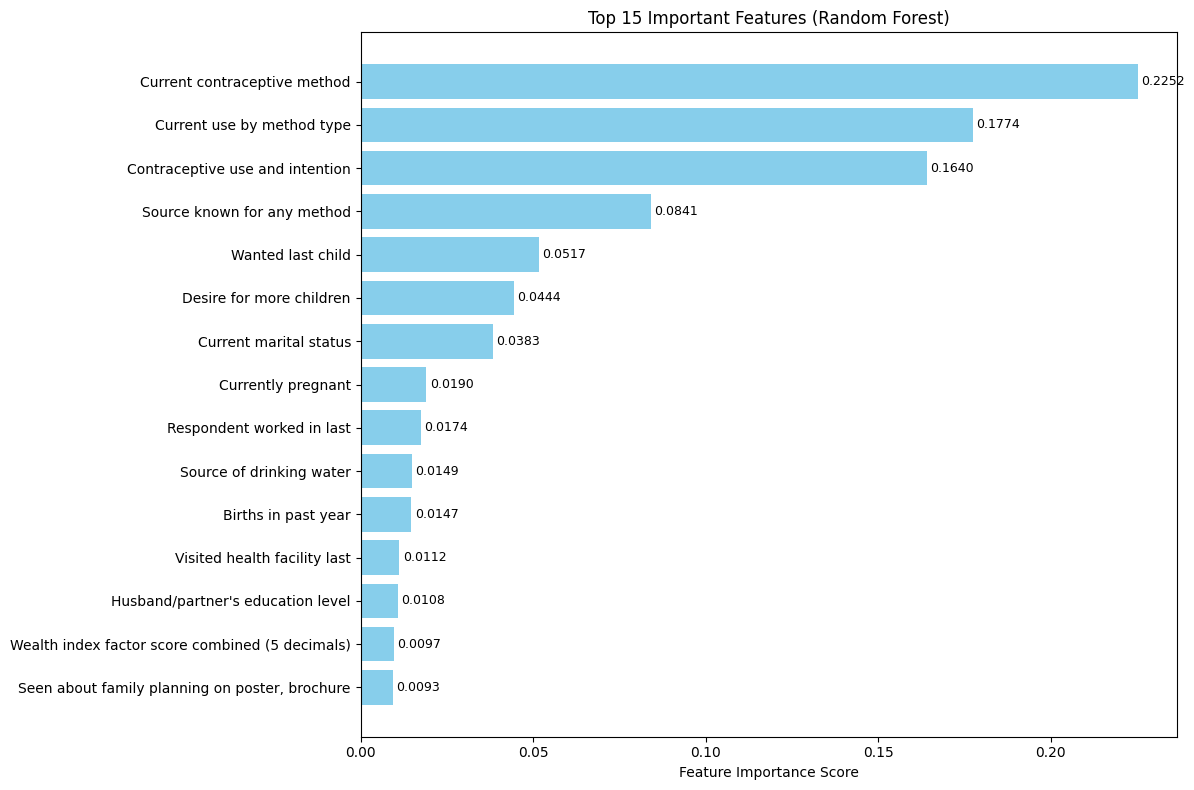

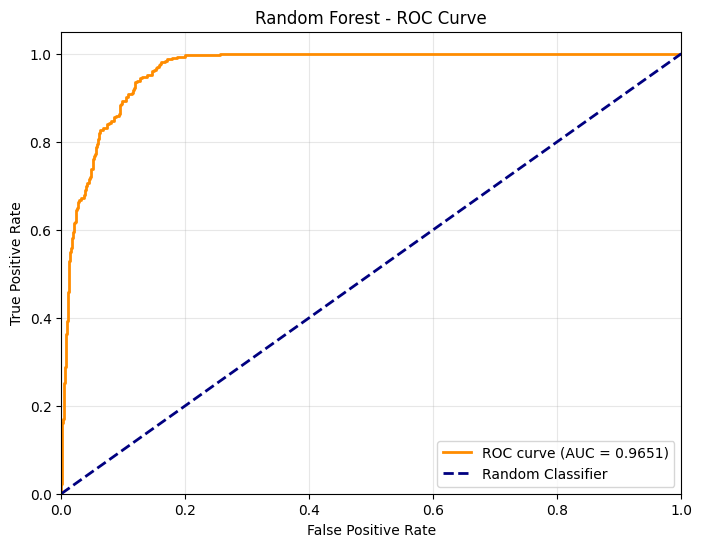


Model Insights
Number of trees trained: 100
Number of features used: 41
Training completed with 2 classes

Feature Importance Statistics:
Max importance: 0.2252
Min importance: 0.0008
Mean importance: 0.0244
Number of features with importance > 0.01: 13


In [22]:
# ======================================================
# 1️⃣ Random Forest with Manual Epoch Tracking
# ======================================================

# Store feature names for later use
feature_names = X_train_resampled.columns

# Scale features (optional for Random Forest, but keeping for consistency)
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_resampled)
X_test_np = scaler.transform(X_test)

y_train_np = y_train_resampled.to_numpy()
y_test_np = y_test.to_numpy()

# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=100,           # Number of trees
    max_depth=10,               # Limit tree depth to prevent overfitting
    min_samples_split=5,        # Minimum samples required to split
    min_samples_leaf=2,         # Minimum samples required at leaf node
    max_features='sqrt',        # Number of features for best split
    class_weight='balanced',    # Handle class imbalance
    random_state=42,
    warm_start=True,            # Allow incremental training
    n_jobs=-1                  # Use all available cores
)

# Manual training with progress tracking
n_epochs = 50
losses, accuracies = [], []

print("Training Random Forest...")
for epoch in range(n_epochs):
    # Train with increasing number of trees
    rf.n_estimators = (epoch + 1) * 2  # Gradually increase trees
    rf.fit(X_train_np, y_train_np)
    
    # Predictions
    y_pred_proba = rf.predict_proba(X_test_np)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Calculate metrics
    losses.append(log_loss(y_test_np, y_pred_proba))
    accuracies.append(accuracy_score(y_test_np, y_pred))
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Trees: {rf.n_estimators} - Loss: {losses[-1]:.4f}, Acc: {accuracies[-1]:.4f}")

# ======================================================
# 2️⃣ Plot loss and accuracy over epochs
# ======================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses, label='Log Loss', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Random Forest - Log Loss Over Time')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Accuracy', color='blue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Random Forest - Accuracy Over Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ======================================================
# 3️⃣ Final evaluation with comprehensive metrics
# ======================================================
y_pred = rf.predict(X_test_np)
y_pred_proba = rf.predict_proba(X_test_np)[:, 1]

print("\n" + "="*50)
print("Random Forest - Final Evaluation")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test_np, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test_np, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_np, y_pred_proba):.4f}")

# Additional metrics
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Feature importance visualization
# ======================================================
importance = rf.feature_importances_
sorted_idx = np.argsort(importance)[::-1]
top_features = np.array(feature_names)[sorted_idx][:15]
top_values = importance[sorted_idx][:15]

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_features)), top_values, color='skyblue')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Important Features (Random Forest)')
plt.gca().invert_yaxis()  # Most important at top

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ======================================================
# 5️⃣ Additional: ROC Curve
# ======================================================
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test_np, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ======================================================
# 6️⃣ Model Insights
# ======================================================
print("\n" + "="*50)
print("Model Insights")
print("="*50)
print(f"Number of trees trained: {rf.n_estimators}")
print(f"Number of features used: {rf.n_features_in_}")
print(f"Training completed with {len(np.unique(y_train_np))} classes")

# Feature importance statistics
print(f"\nFeature Importance Statistics:")
print(f"Max importance: {importance.max():.4f}")
print(f"Min importance: {importance.min():.4f}")
print(f"Mean importance: {importance.mean():.4f}")
print(f"Number of features with importance > 0.01: {np.sum(importance > 0.01)}")


## LightGBM

In [24]:
import lightgbm as lgb

Training until validation scores don't improve for 20 rounds
[20]	train's binary_logloss: 0.27901	train's auc: 0.993726	valid's binary_logloss: 0.326004	valid's auc: 0.962919
[40]	train's binary_logloss: 0.153228	train's auc: 0.995405	valid's binary_logloss: 0.222986	valid's auc: 0.965458
[60]	train's binary_logloss: 0.103195	train's auc: 0.997377	valid's binary_logloss: 0.188166	valid's auc: 0.967013
[80]	train's binary_logloss: 0.0760326	train's auc: 0.998545	valid's binary_logloss: 0.173929	valid's auc: 0.968281
[100]	train's binary_logloss: 0.0603016	train's auc: 0.999137	valid's binary_logloss: 0.16889	valid's auc: 0.969155
[120]	train's binary_logloss: 0.0494751	train's auc: 0.999579	valid's binary_logloss: 0.165821	valid's auc: 0.97
[140]	train's binary_logloss: 0.0415335	train's auc: 0.9998	valid's binary_logloss: 0.163268	valid's auc: 0.970994
[160]	train's binary_logloss: 0.0348222	train's auc: 0.999927	valid's binary_logloss: 0.162829	valid's auc: 0.971208
[180]	train's bina

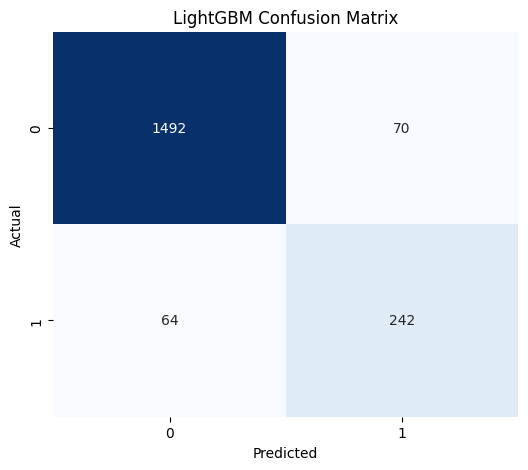

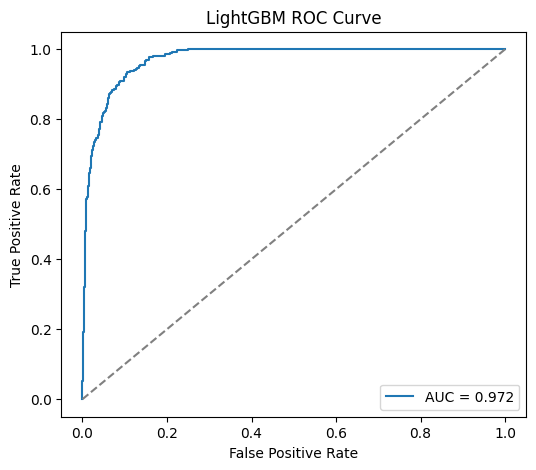

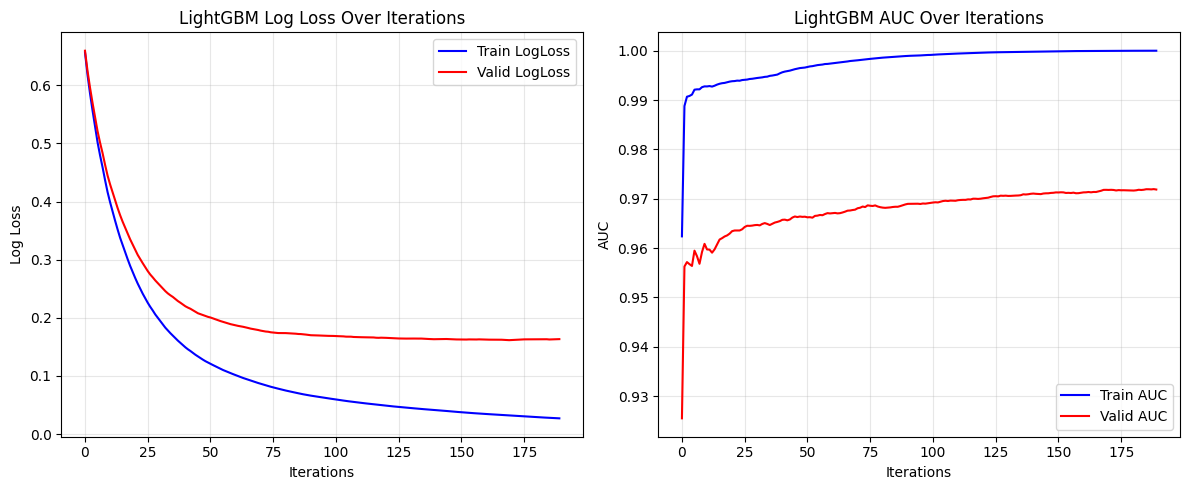

C:\Users\HP\AppData\Local\Temp\ipykernel_13568\3582659318.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')


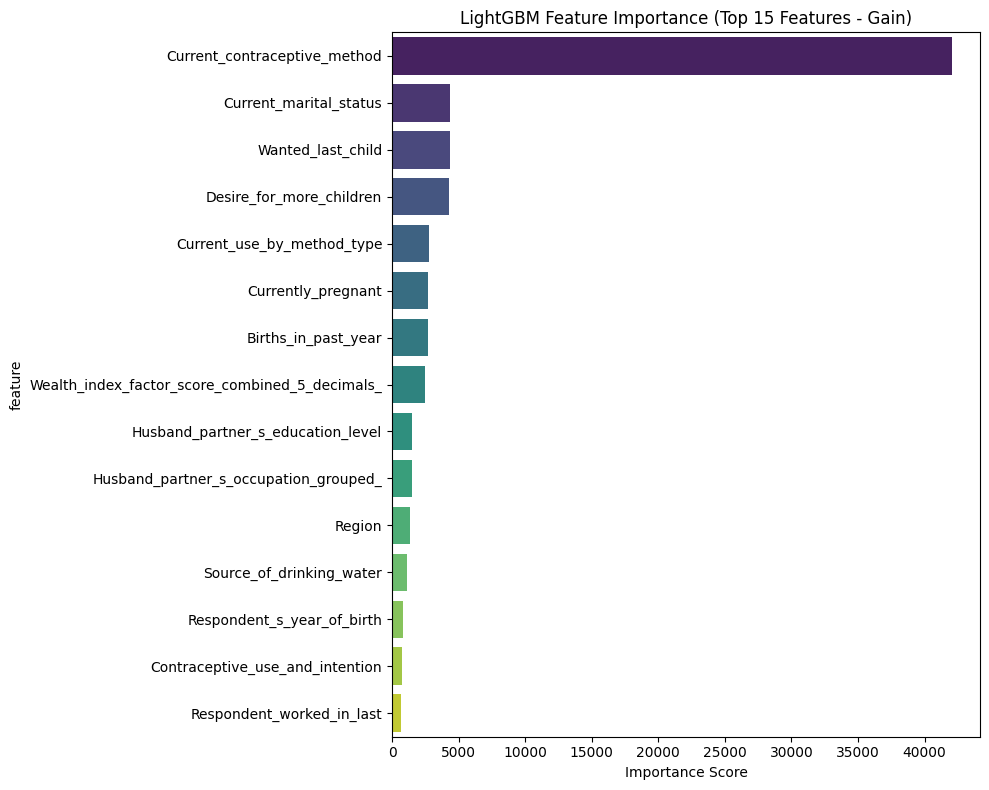

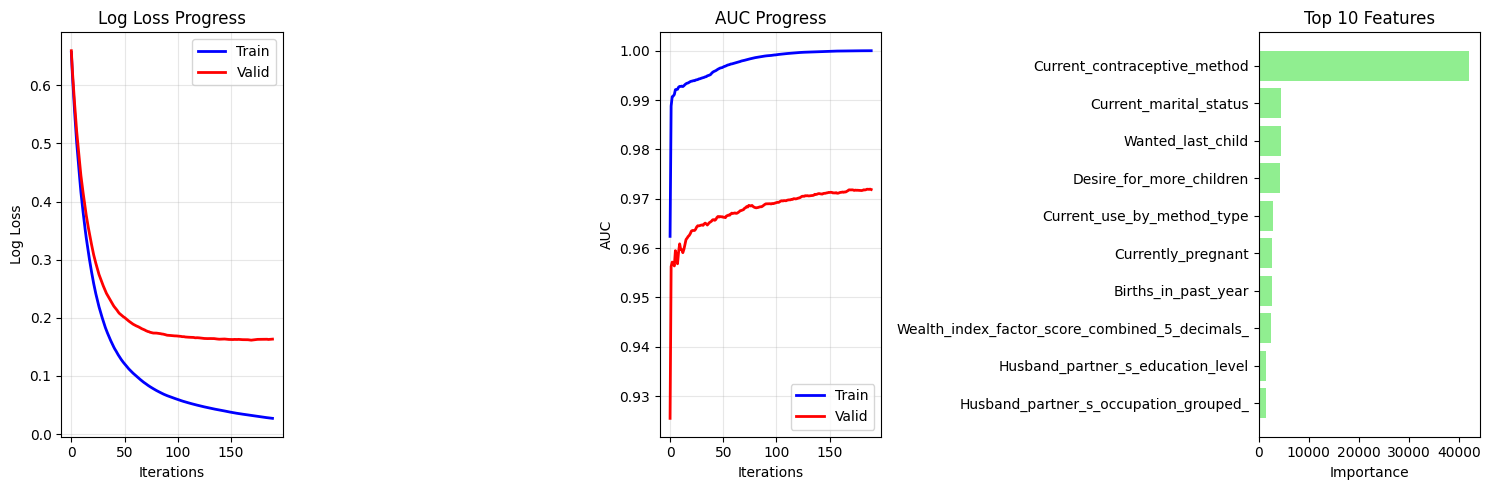


LightGBM Model Insights
Best iteration: 170
Total iterations run: 190
Number of features: 41
Best validation AUC: 0.9719
Best validation log loss: 0.1616

Feature Importance Statistics:
Max importance: 42064.4
Min importance: 41.8
Mean importance: 1978.1
Number of features with importance > 0: 41


In [30]:
# ================================
# 0. Clean feature names (FIXED - use original DataFrames)
# ================================
# Clean feature names on the original DataFrames before converting to numpy
X_train_resampled.columns = X_train_resampled.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# Store cleaned feature names for later use
feature_names = X_train_resampled.columns

# Convert to numpy arrays if needed (LightGBM can handle DataFrames directly)
X_train_clean = X_train_resampled
X_test_clean = X_test

# ================================
# 1. Prepare LightGBM Dataset
# ================================
lgb_train = lgb.Dataset(X_train_clean, label=y_train_resampled)
lgb_test = lgb.Dataset(X_test_clean, label=y_test, reference=lgb_train)

# ================================
# 2. Set Parameters
# ================================
params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "seed": 42,
    "verbose": -1
}

# ================================
# 3. Train Model
# ================================
evals_result = {}

gbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_test],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=20),
        lgb.record_evaluation(evals_result)
    ]
)

# ================================
# 4. Predictions
# ================================
y_pred_proba = gbm.predict(X_test_clean, num_iteration=gbm.best_iteration)
y_pred = (y_pred_proba > 0.5).astype(int)

# ================================
# 5. Evaluation Metrics
# ================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n📊 LightGBM Evaluation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ================================
# 6. Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 7. ROC Curve
# ================================
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()

# ================================
# 8. Training Metrics Plot
# ================================
# Get the actual number of iterations that were run (due to early stopping)
actual_iterations = len(evals_result["train"]["binary_logloss"])
x_axis = range(0, actual_iterations)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_axis, evals_result["train"]["binary_logloss"], label="Train LogLoss", color='blue')
plt.plot(x_axis, evals_result["valid"]["binary_logloss"], label="Valid LogLoss", color='red')
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("LightGBM Log Loss Over Iterations")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x_axis, evals_result["train"]["auc"], label="Train AUC", color='blue')
plt.plot(x_axis, evals_result["valid"]["auc"], label="Valid AUC", color='red')
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.title("LightGBM AUC Over Iterations")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# 9. Feature Importance (FIXED - using stored feature names)
# ================================
importance = gbm.feature_importance(importance_type='gain')
feature_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_imp_df.head(15)
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title('LightGBM Feature Importance (Top 15 Features - Gain)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ================================
# 10. Additional: Learning Progress (Loss & Accuracy)
# ================================
# Calculate accuracy for each iteration to match your previous models
train_accuracies = []
valid_accuracies = []

for i in range(actual_iterations):
    # For training accuracy, we'd need to predict on training data at each iteration
    # This is computationally expensive, so we'll focus on the loss and AUC which are already tracked
    
    # Alternatively, we can plot what we have
    pass

# Plot comprehensive learning curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, evals_result["train"]["binary_logloss"], label="Train", color='blue', linewidth=2)
plt.plot(x_axis, evals_result["valid"]["binary_logloss"], label="Valid", color='red', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Log Loss Progress")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(x_axis, evals_result["train"]["auc"], label="Train", color='blue', linewidth=2)
plt.plot(x_axis, evals_result["valid"]["auc"], label="Valid", color='red', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.title("AUC Progress")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Feature importance bar plot for top 10
top_10_features = feature_imp_df.head(10)
plt.barh(range(len(top_10_features)), top_10_features['importance'], color='lightgreen')
plt.yticks(range(len(top_10_features)), top_10_features['feature'])
plt.xlabel('Importance')
plt.title('Top 10 Features')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# ================================
# 11. Model Insights
# ================================
print("\n" + "="*50)
print("LightGBM Model Insights")
print("="*50)
print(f"Best iteration: {gbm.best_iteration}")
print(f"Total iterations run: {actual_iterations}")
print(f"Number of features: {len(feature_names)}")
print(f"Best validation AUC: {max(evals_result['valid']['auc']):.4f}")
print(f"Best validation log loss: {min(evals_result['valid']['binary_logloss']):.4f}")

# Feature importance statistics
print(f"\nFeature Importance Statistics:")
print(f"Max importance: {importance.max():.1f}")
print(f"Min importance: {importance.min():.1f}")
print(f"Mean importance: {importance.mean():.1f}")
print(f"Number of features with importance > 0: {np.sum(importance > 0)}")

## XGBoost

In [31]:
import xgboost as xgb

Training XGBoost...
[0]	train-logloss:0.65300	train-auc:0.98040	valid-logloss:0.65535	valid-auc:0.95826
[20]	train-logloss:0.28570	train-auc:0.99112	valid-logloss:0.32178	valid-auc:0.96499
[40]	train-logloss:0.17203	train-auc:0.99267	valid-logloss:0.22636	valid-auc:0.96503
[60]	train-logloss:0.12842	train-auc:0.99447	valid-logloss:0.19476	valid-auc:0.96546
[80]	train-logloss:0.10566	train-auc:0.99585	valid-logloss:0.18050	valid-auc:0.96628
[100]	train-logloss:0.09188	train-auc:0.99682	valid-logloss:0.17384	valid-auc:0.96736
[120]	train-logloss:0.08090	train-auc:0.99764	valid-logloss:0.16961	valid-auc:0.96845
[140]	train-logloss:0.07080	train-auc:0.99842	valid-logloss:0.16601	valid-auc:0.96949
[160]	train-logloss:0.06349	train-auc:0.99886	valid-logloss:0.16389	valid-auc:0.97024
[180]	train-logloss:0.05658	train-auc:0.99922	valid-logloss:0.16285	valid-auc:0.97033
[191]	train-logloss:0.05374	train-auc:0.99934	valid-logloss:0.16269	valid-auc:0.97054

📊 XGBoost Evaluation Metrics:
Accuracy:

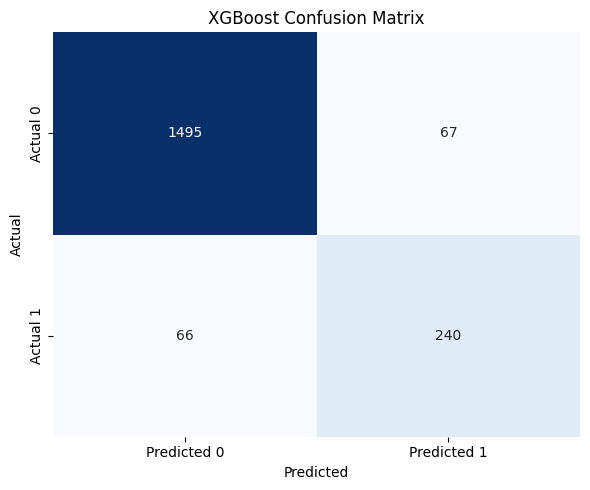

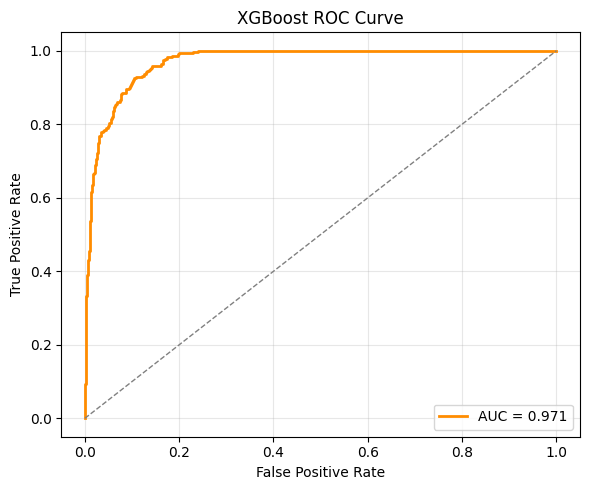

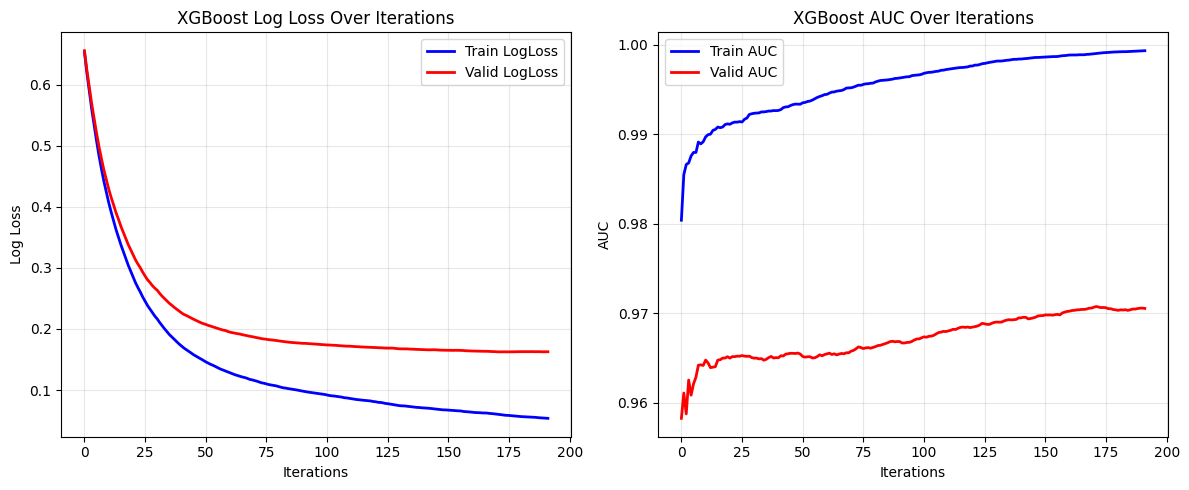

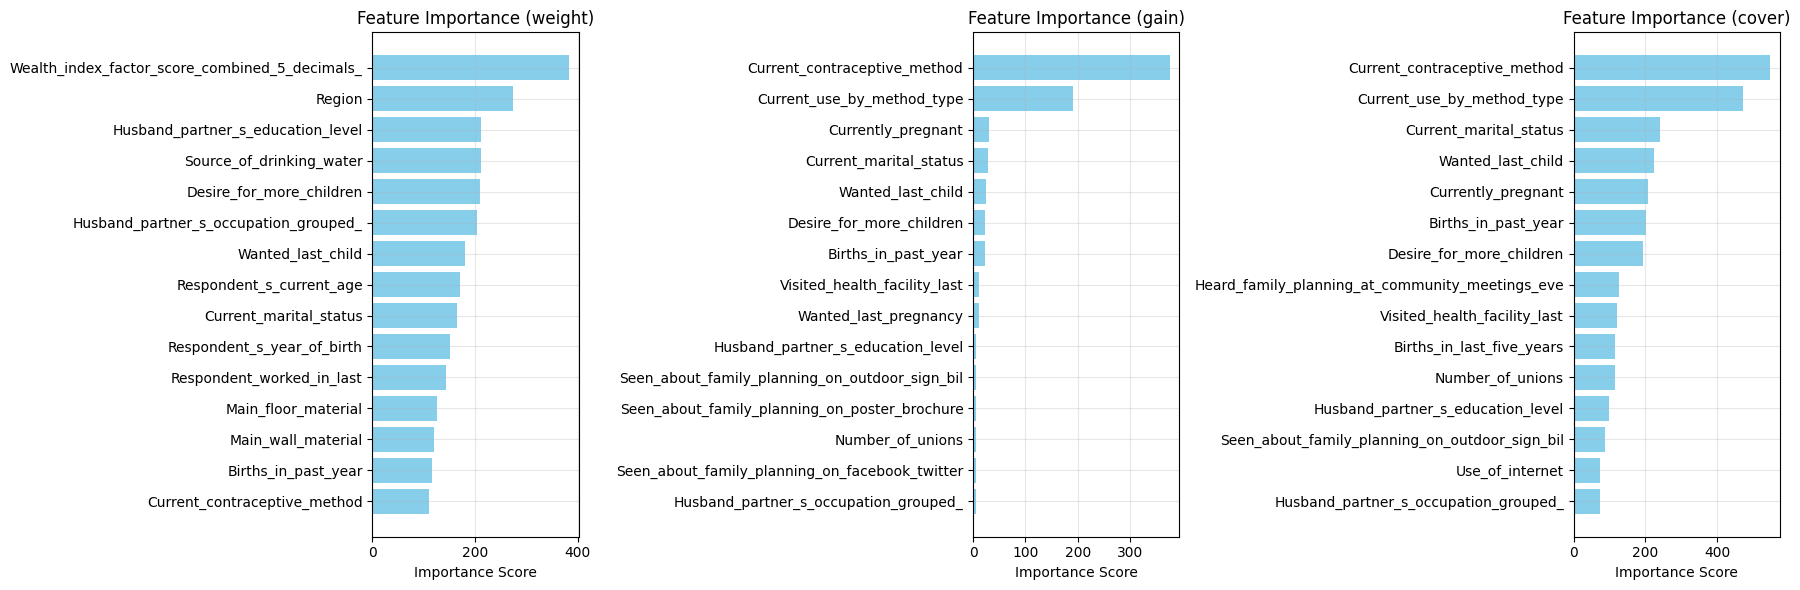

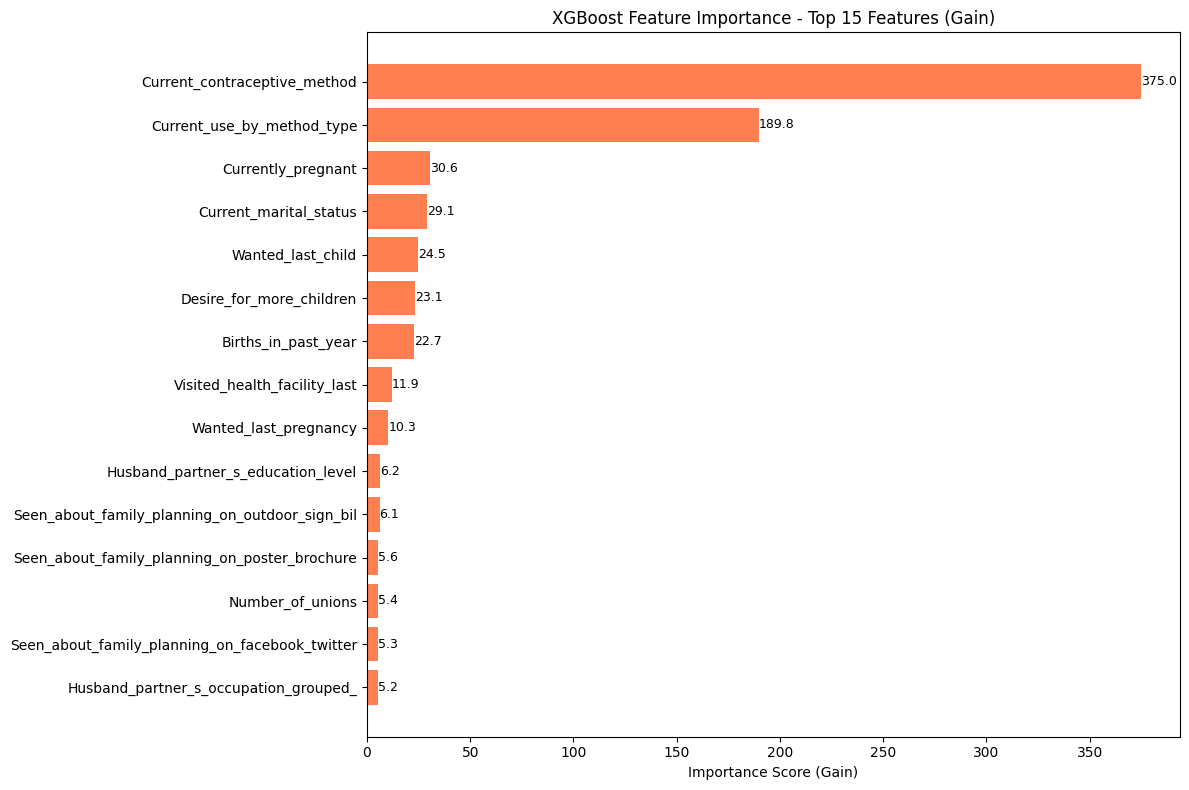

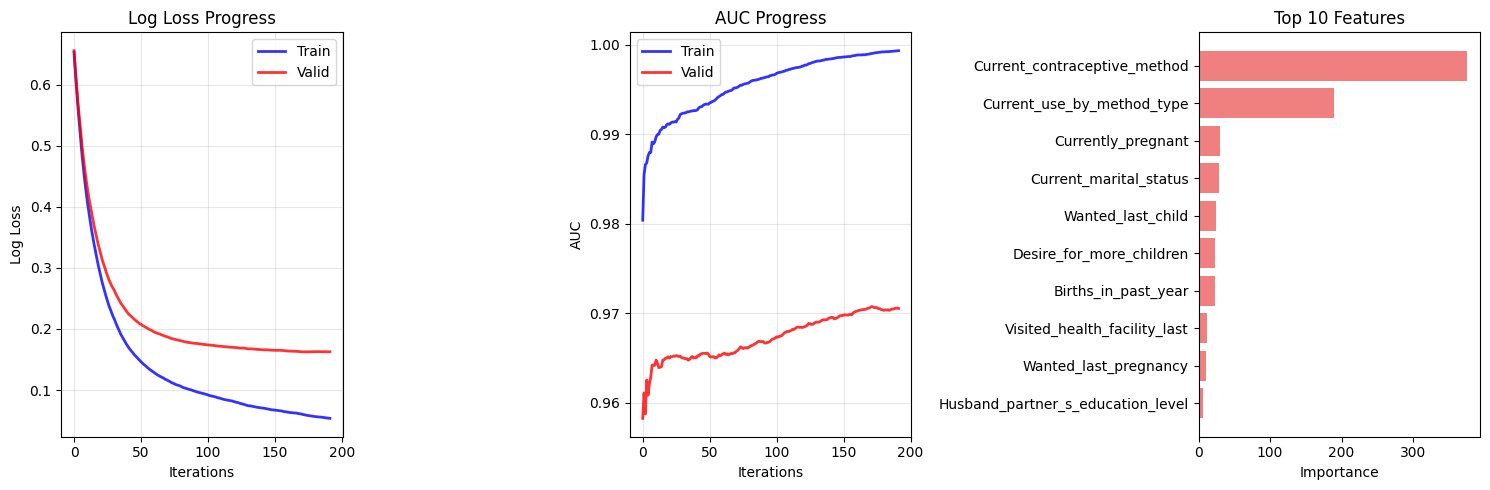

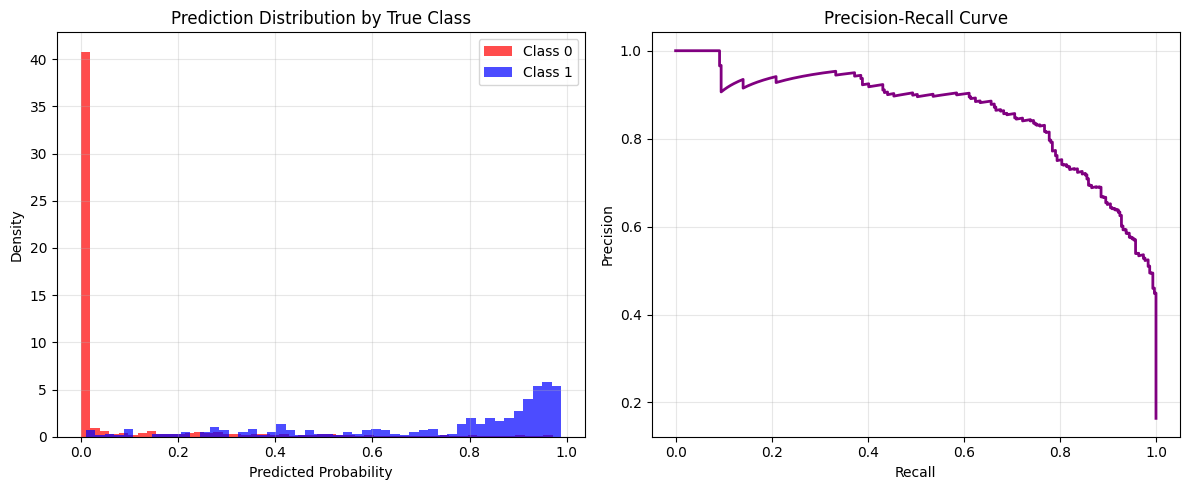


XGBoost Model Insights
Best iteration: 171
Total iterations run: 192
Number of features: 41
Best validation AUC: 0.9708
Best validation log loss: 0.1625
Scale pos weight (for imbalance): 1.00

Feature Importance Statistics (Gain):
Max importance: 375.0
Min importance: 2.5
Mean importance: 20.6
Number of features with importance > 0: 41
Top 5 most important features:
  Respondent_s_current_age: 2.8
  Respondent_s_year_of_birth: 3.1
  Highest_educational_level: 2.5
  Region: 3.5
  Current_marital_status: 29.1

Cross-Validation Results
Best CV AUC: 0.9920 (+/- 0.0021)
Best CV LogLoss: 0.1179 (+/- 0.0099)
Optimal number of rounds: 100


In [33]:
# ================================
# 0. Clean feature names and prepare data
# ================================
# Clean feature names on the original DataFrames
X_train_resampled.columns = X_train_resampled.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# Store cleaned feature names for later use (convert to list)
feature_names = X_train_resampled.columns.tolist()  # FIX: Convert to list

# Convert to DMatrix format for XGBoost
dtrain = xgb.DMatrix(X_train_resampled, label=y_train_resampled, feature_names=feature_names)  # FIX: Now it's a list
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)  # FIX: Now it's a list

# ================================
# 1. Set XGBoost Parameters
# ================================
params = {
    "objective": "binary:logistic",
    "eval_metric": ["logloss", "auc"],
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "alpha": 0.1,
    "lambda": 0.1,
    "seed": 42,
    "scale_pos_weight": len(y_train_resampled[y_train_resampled == 0]) / len(y_train_resampled[y_train_resampled == 1])  # Handle imbalance
}

# ================================
# 2. Train Model with Progress Tracking
# ================================
print("Training XGBoost...")

# Train with early stopping and progress tracking
evals_result = {}
num_rounds = 200

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_rounds,
    evals=[(dtrain, "train"), (dtest, "valid")],
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=20  # Print progress every 20 iterations
)

# ================================
# 3. Predictions
# ================================
y_pred_proba = bst.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)

# ================================
# 4. Evaluation Metrics
# ================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n📊 XGBoost Evaluation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")
print(f"Best Iteration: {bst.best_iteration}")
print(f"Best Score: {bst.best_score:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ================================
# 5. Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ================================
# 6. ROC Curve
# ================================
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ================================
# 7. Training Metrics Plot
# ================================
# Get the actual number of iterations that were run
actual_iterations = len(evals_result["train"]["logloss"])
x_axis = range(0, actual_iterations)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_axis, evals_result["train"]["logloss"], label="Train LogLoss", color='blue', linewidth=2)
plt.plot(x_axis, evals_result["valid"]["logloss"], label="Valid LogLoss", color='red', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("XGBoost Log Loss Over Iterations")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x_axis, evals_result["train"]["auc"], label="Train AUC", color='blue', linewidth=2)
plt.plot(x_axis, evals_result["valid"]["auc"], label="Valid AUC", color='red', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.title("XGBoost AUC Over Iterations")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# 8. Feature Importance
# ================================
# Get feature importance
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, importance_type in enumerate(importance_types):
    importance = bst.get_score(importance_type=importance_type)
    
    if importance:  # Check if importance dict is not empty
        # Convert to DataFrame for easier plotting
        imp_df = pd.DataFrame({
            'feature': list(importance.keys()),
            'importance': list(importance.values())
        }).sort_values('importance', ascending=True).tail(15)  # Top 15
        
        axes[i].barh(imp_df['feature'], imp_df['importance'], color='skyblue')
        axes[i].set_title(f'Feature Importance ({importance_type})')
        axes[i].set_xlabel('Importance Score')
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'No {importance_type}\nimportance data', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'Feature Importance ({importance_type})')

plt.tight_layout()
plt.show()

# Main feature importance plot (using gain)
importance_gain = bst.get_score(importance_type='gain')
if importance_gain:  # Check if gain importance is available
    feature_imp_df = pd.DataFrame({
        'feature': list(importance_gain.keys()),
        'importance': list(importance_gain.values())
    }).sort_values('importance', ascending=False)

    # Plot top 15 features
    plt.figure(figsize=(12, 8))
    top_features = feature_imp_df.head(15)
    bars = plt.barh(range(len(top_features)), top_features['importance'], color='coral')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance Score (Gain)')
    plt.title('XGBoost Feature Importance - Top 15 Features (Gain)')
    plt.gca().invert_yaxis()

    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{width:.1f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    # Alternative: Use weight importance if gain is not available
    importance_weight = bst.get_score(importance_type='weight')
    if importance_weight:
        feature_imp_df = pd.DataFrame({
            'feature': list(importance_weight.keys()),
            'importance': list(importance_weight.values())
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(12, 8))
        top_features = feature_imp_df.head(15)
        bars = plt.barh(range(len(top_features)), top_features['importance'], color='coral')
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Importance Score (Weight)')
        plt.title('XGBoost Feature Importance - Top 15 Features (Weight)')
        plt.gca().invert_yaxis()

        for i, bar in enumerate(bars):
            width = bar.get_width()
            plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                     f'{width:.0f}', ha='left', va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

# ================================
# 9. Learning Progress Comparison
# ================================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, evals_result["train"]["logloss"], label="Train", color='blue', linewidth=2, alpha=0.8)
plt.plot(x_axis, evals_result["valid"]["logloss"], label="Valid", color='red', linewidth=2, alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Log Loss Progress")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(x_axis, evals_result["train"]["auc"], label="Train", color='blue', linewidth=2, alpha=0.8)
plt.plot(x_axis, evals_result["valid"]["auc"], label="Valid", color='red', linewidth=2, alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.title("AUC Progress")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Feature importance bar plot for top 10
if 'feature_imp_df' in locals() and len(feature_imp_df) > 0:
    top_10_features = feature_imp_df.head(10)
    plt.barh(range(len(top_10_features)), top_10_features['importance'], color='lightcoral')
    plt.yticks(range(len(top_10_features)), top_10_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 10 Features')
    plt.gca().invert_yaxis()
else:
    plt.text(0.5, 0.5, 'No feature importance\ndata available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Top 10 Features')

plt.tight_layout()
plt.show()

# ================================
# 10. Prediction Distribution
# ================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Class 0', color='red', density=True)
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Class 1', color='blue', density=True)
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Prediction Distribution by True Class')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Precision-Recall curve
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# 11. Model Insights
# ================================
print("\n" + "="*50)
print("XGBoost Model Insights")
print("="*50)
print(f"Best iteration: {bst.best_iteration}")
print(f"Total iterations run: {actual_iterations}")
print(f"Number of features: {len(feature_names)}")
print(f"Best validation AUC: {max(evals_result['valid']['auc']):.4f}")
print(f"Best validation log loss: {min(evals_result['valid']['logloss']):.4f}")
print(f"Scale pos weight (for imbalance): {params['scale_pos_weight']:.2f}")

# Feature importance statistics
importance_gain = bst.get_score(importance_type='gain')
if importance_gain:
    importance_values = list(importance_gain.values())
    print(f"\nFeature Importance Statistics (Gain):")
    print(f"Max importance: {max(importance_values):.1f}")
    print(f"Min importance: {min(importance_values):.1f}")
    print(f"Mean importance: {np.mean(importance_values):.1f}")
    print(f"Number of features with importance > 0: {len(importance_gain)}")
    print(f"Top 5 most important features:")
    for i, (feature, imp) in enumerate(list(importance_gain.items())[:5]):
        print(f"  {feature}: {imp:.1f}")
else:
    print("\nNo gain-based feature importance available.")

# ================================
# 12. Cross-Validation (Optional)
# ================================
print("\n" + "="*50)
print("Cross-Validation Results")
print("="*50)

# Perform cross-validation
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=100,
    nfold=5,
    metrics=['logloss', 'auc'],
    early_stopping_rounds=10,
    stratified=True,
    seed=42
)

print(f"Best CV AUC: {cv_results['test-auc-mean'].max():.4f} (+/- {cv_results['test-auc-std'][cv_results['test-auc-mean'].idxmax()]:.4f})")
print(f"Best CV LogLoss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'][cv_results['test-logloss-mean'].idxmin()]:.4f})")
print(f"Optimal number of rounds: {len(cv_results)}")